# Rudimentary peak calling take 1

In [1]:
from pathlib import Path
import subprocess

import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import config

In [18]:
modkit_exe = Path("/Users/jeremy/devspace/cargo_local/bin/modkit")

# Starting with chr11 as a test (the pileup for the browser happens to be all of chr11)
pileup_file = config.processed_data_dir / "pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.browser" / "pileup.sorted.bed.gz"
ctcf_chip_seq_file = Path("/Users/jeremy/devspace/multimodal-dimelo/review_data/chr11_ctcf_chip_peaks.bed")
# tss_file = Path("/Users/jeremy/devspace/multimodal-dimelo/review_data/chr11_q4_tss.slop250.bed")
window_file = Path("/Users/jeremy/devspace/reference_data/beds/chm13v2.0_windows_1000bp/chm13v2.0_windows_1000bp_chr11.bed")


output_dir = config.working_dir / "review_data"

modkit_stats_file = output_dir / "modkit_stats_chr11_1000bp.tsv"
label_file = output_dir / "window_labels_chr11_1000bp.tsv"
ctcf_chip_window_assignment_file = output_dir / "ctcf_chip_assignments_chr11_1000bp.tsv"

## Compute mA counts in each window using `modkit stats`

In [3]:
subprocess.run(f"{modkit_exe} stats {pileup_file} --regions {window_file} -o {modkit_stats_file}", shell=True)

> Error! File exists (os error 17)


CompletedProcess(args='/Users/jeremy/devspace/cargo_local/bin/modkit stats /Users/jeremy/devspace/multimodal-dimelo/data/processed/pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.browser/pileup.sorted.bed.gz --regions /Users/jeremy/devspace/reference_data/beds/chm13v2.0_windows_1000bp/chm13v2.0_windows_1000bp_chr11.bed -o /Users/jeremy/devspace/multimodal-dimelo/review_data/modkit_stats_chr11_1000bp.tsv', returncode=1)

## Get labels for each window

count overlaps with ChIP peaks for each window, then coerce them to booleans

In [4]:
subprocess.run(f"bedtools intersect -a {window_file} -b {ctcf_chip_seq_file} -C | awk -F '\t' 'BEGIN {{OFS = FS}} $4 > 1 {{ $4 = 1 }} {{print}}' > {label_file}", shell=True)

CompletedProcess(args="bedtools intersect -a /Users/jeremy/devspace/reference_data/beds/chm13v2.0_windows_1000bp/chm13v2.0_windows_1000bp_chr11.bed -b /Users/jeremy/devspace/multimodal-dimelo/review_data/chr11_ctcf_chip_peaks.bed -C | awk -F '\t' 'BEGIN {OFS = FS} $4 > 1 { $4 = 1 } {print}' > /Users/jeremy/devspace/multimodal-dimelo/review_data/window_labels_chr11_1000bp.tsv", returncode=0)

## Get windows overlapping each ChIP peak

Generates a "BED" file, where the first 3 cols correspond to the genomic window and the second 3 cols correspond to the ChIP peak.

In [5]:
subprocess.run(f"bedtools intersect -a {window_file} -b {ctcf_chip_seq_file} -wao | cut -f 1-6 > {ctcf_chip_window_assignment_file}", shell=True)

CompletedProcess(args='bedtools intersect -a /Users/jeremy/devspace/reference_data/beds/chm13v2.0_windows_1000bp/chm13v2.0_windows_1000bp_chr11.bed -b /Users/jeremy/devspace/multimodal-dimelo/review_data/chr11_ctcf_chip_peaks.bed -wao | cut -f 1-6 > /Users/jeremy/devspace/multimodal-dimelo/review_data/ctcf_chip_assignments_chr11_1000bp.tsv', returncode=0)

In [286]:
start = 100580280
end = 100580830
(start + end) / 2

100580555.0

In [287]:
print(100580555 - start, end - 100580555)

275 275


## Modeling

In [3]:
modkit_stats_df = pd.read_csv(modkit_stats_file, sep="\t")[["#chrom", "start", "end", "count_a", "count_valid_a"]]

In [4]:
modkit_stats_df

,#chrom,start,end,count_a,count_valid_a
0,chr11,0,1000,645,15396
1,chr11,1000,2000,505,18281
2,chr11,2000,3000,69,12436
3,chr11,3000,4000,163,26293
4,chr11,4000,5000,133,18701
...,...,...,...,...,...
135123,chr11,135123000,135124000,63,9779
135124,chr11,135124000,135125000,9,2880
135125,chr11,135125000,135126000,156,5728
135126,chr11,135126000,135127000,130,6212


Setting background parameters

In [8]:
# Option 1: averages
alpha = np.round(modkit_stats_df["count_a"].mean())
beta = np.round(modkit_stats_df["count_valid_a"].mean() - alpha)
print(f"alpha: {alpha}, beta: {beta}")

alpha: 40.0, beta: 7944.0


In [9]:
# Option 2: medians
# alpha = df["count_a"].median()
# beta = df["count_valid_a"].median() - alpha
# print(f"alpha: {alpha}, beta: {beta}")

Plot distribution of methylation fractions, and visualize where the estimated background parameters sit

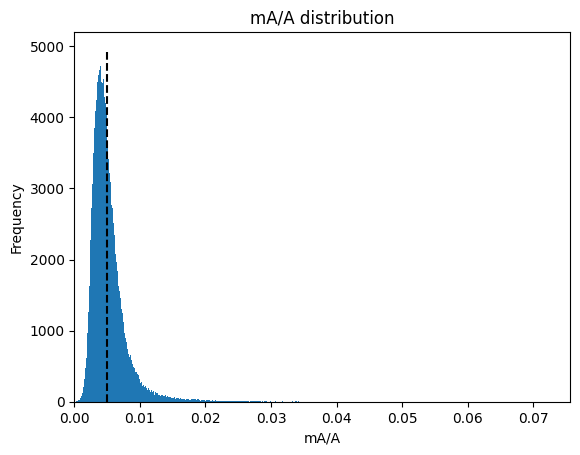

In [10]:
(modkit_stats_df["count_a"] / modkit_stats_df["count_valid_a"]).plot.hist(bins=500)
y_min, y_max = plt.ylim()
plt.vlines(alpha / (alpha + beta), y_min, y_max, color="k", linestyle="--")
plt.xlim([0, None])
plt.xlabel("mA/A")
plt.title("mA/A distribution")
plt.show()

Sanity check plots for a window of the average size

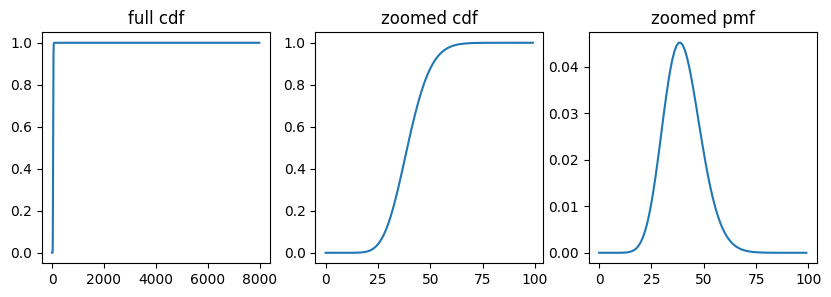

In [11]:
n = int(alpha + beta)
x = np.linspace(0, n, n+1)
y = stats.betabinom.cdf(x, n, alpha, beta)
fig, axs = plt.subplots(1, 3, figsize=(10,3))
axs[0].plot(x, y)
axs[0].set_title("full cdf")
axs[1].plot(x[:100], y[:100])
axs[1].set_title("zoomed cdf")
y = stats.betabinom.pmf(x, n, alpha, beta)
axs[2].plot(x[:100], y[:100])
axs[2].set_title("zoomed pmf")
plt.show()

Applying the test to the data

In [12]:
modkit_stats_df["prob"] = modkit_stats_df.apply(lambda row: 1 - stats.betabinom.cdf(k=row["count_a"], n=row["count_valid_a"], a=alpha, b=beta), axis="columns")

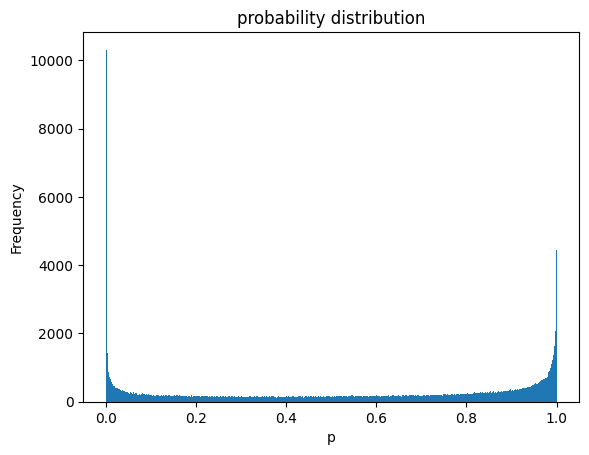

In [13]:
modkit_stats_df["prob"].plot.hist(bins=500)
plt.xlabel("p")
plt.title("probability distribution")
plt.show()

## Evaluation

Load labels and calculate outcomes

In [14]:
label_df = pd.read_csv(label_file, sep="\t", header=None, names=["#chrom", "start", "end", "label"])

positives = label_df["label"].sum()
negatives = len(label_df) - positives

In [ ]:
labeled_stats_df = pd.merge(modkit_stats_df, label_df, on=["#chrom", "start", "end"]).sort_values("prob").reset_index(drop=True)

# These are surprisingly effective and efficient; are they idiomatic?
# How they work: Because it is sorted by probability, 1. count how many positive labels have been observed up until each row, 2. replace this count with the maximum count observed over all rows with that probability
labeled_stats_df["TP"] = labeled_stats_df["label"].expanding().sum()
labeled_stats_df["TP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["TP"])

labeled_stats_df["FP"] = (labeled_stats_df["label"] == 0).expanding().sum()
labeled_stats_df["FP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["FP"])

labeled_stats_df["FN"] = positives - labeled_stats_df["TP"]
labeled_stats_df["TN"] = negatives - labeled_stats_df["FP"]

labeled_stats_df["TPR"] = labeled_stats_df["TP"] / positives
labeled_stats_df["FPR"] = labeled_stats_df["FP"] / negatives

# TODO: Rename this column.
# Contains the fraction of the rows that would be returned as a hit if the probability for that row was the threshold
labeled_stats_df["hit_fraction"] = (labeled_stats_df["prob"].rank(method="min") - 1) / len(labeled_stats_df)

Load CTCF ChIP peak assignments and calculate ChIP recovery

In [16]:
ctcf_chip_peak_df = pd.read_csv(ctcf_chip_window_assignment_file, sep="\t", header=None, names=["#chrom", "start", "end", "chip_chr", "chip_start", "chip_end"])
# Turn ChIP peak locations into unique identifiers
ctcf_chip_peak_df["chip_ids"] = ctcf_chip_peak_df[["chip_chr", "chip_start", "chip_end"]].astype("str").agg(":".join, axis="columns")
# Drop windows that have no assigned peaks; group peak assignments together for each genomic window
ctcf_chip_peak_df = ctcf_chip_peak_df[["#chrom", "start", "end", "chip_ids"]].query("chip_ids != '.:-1:-1'").groupby(["#chrom", "start", "end"]).agg({"chip_ids": set}).reset_index()

# TODO: assert that this is the correct number based off of the count from the original ChIP file
n_chip_hits = ctcf_chip_peak_df["chip_ids"].explode().nunique()
n_chip_hits

2335

In [ ]:
labeled_stats_df = pd.merge(labeled_stats_df, ctcf_chip_peak_df, how="left", on=["#chrom", "start", "end"])

In [18]:
captured_set = set()
chip_hits = []
for chip_id_set in labeled_stats_df["chip_ids"]:
    if chip_id_set is not np.nan:
        captured_set = captured_set.union(chip_id_set)
    chip_hits.append(len(captured_set))
labeled_stats_df["ChIP Recovery Fraction"] = np.array(chip_hits) / n_chip_hits
# replace this count with the maximum count observed over all rows with that probability
labeled_stats_df["ChIP Recovery Fraction"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["ChIP Recovery Fraction"])

In [19]:
labeled_stats_df

,#chrom,start,end,count_a,count_valid_a,prob,label,TP,FP,FN,TN,TPR,FPR,hit_fraction,chip_ids,ChIP Recovery Fraction
0,chr11,135127000,135127769,133,4167,0.0,0,323.0,553.0,2598.0,131654.0,0.110579,0.004183,0.000000,NaN,0.143041
1,chr11,64716000,64717000,55,2631,0.0,1,323.0,553.0,2598.0,131654.0,0.110579,0.004183,0.000000,{chr11:64716760:64716991},0.143041
2,chr11,64736000,64737000,110,3551,0.0,1,323.0,553.0,2598.0,131654.0,0.110579,0.004183,0.000000,"{chr11:64736780:64737136, chr11:64736080:64736...",0.143041
3,chr11,64737000,64738000,124,4373,0.0,1,323.0,553.0,2598.0,131654.0,0.110579,0.004183,0.000000,{chr11:64736780:64737136},0.143041
4,chr11,64772000,64773000,200,5516,0.0,0,323.0,553.0,2598.0,131654.0,0.110579,0.004183,0.000000,NaN,0.143041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135123,chr11,38794000,38795000,2,5916,1.0,0,2921.0,132203.0,0.0,4.0,1.000000,0.999970,0.999963,NaN,1.000000
135124,chr11,39023000,39024000,13,12941,1.0,0,2921.0,132204.0,0.0,3.0,1.000000,0.999977,0.999970,NaN,1.000000
135125,chr11,133726000,133727000,6,8689,1.0,0,2921.0,132205.0,0.0,2.0,1.000000,0.999985,0.999978,NaN,1.000000
135126,chr11,48985000,48986000,9,10768,1.0,0,2921.0,132206.0,0.0,1.0,1.000000,0.999992,0.999985,NaN,1.000000


Visualize performance, based on a particular threshold

In [35]:
# TODO: Why does seaborn lineplot take forever to plot these but plotly does it just fine?
threshold = 0.05
threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
threshold_n_hits = threshold_row.name

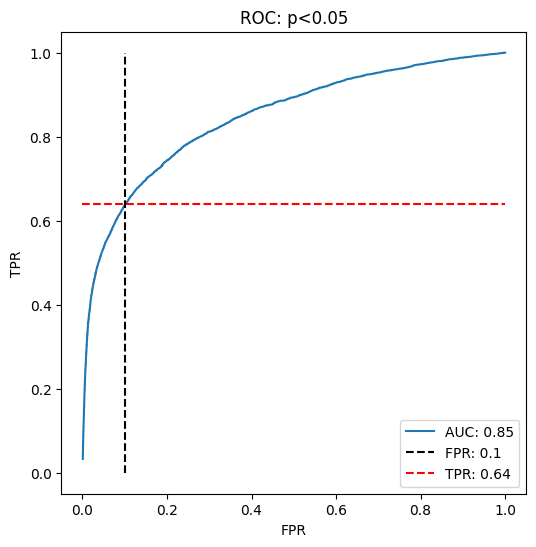

In [37]:
auc = np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"])
plt.figure(figsize=(6,6))
plt.plot(labeled_stats_df["FPR"], labeled_stats_df["TPR"], label=f"AUC: {auc:.2}")
plt.vlines(x=threshold_row["FPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'FPR: {threshold_row["FPR"]:.2}')
plt.hlines(y=threshold_row["TPR"], xmin=0, xmax=1, color="r", linestyle="--", label=f'TPR: {threshold_row["TPR"]:.2}')
plt.legend(loc="lower right")
plt.title(f"ROC: p<{threshold}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

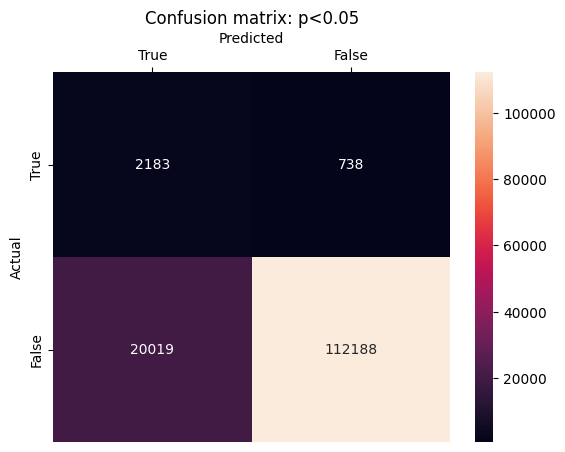

In [22]:
cm = np.reshape(threshold_row[["TP", "FN", "FP", "TN"]], (2,2)).astype("int")

ax = sns.heatmap(cm, annot=True, fmt="", xticklabels=["True", "False"], yticklabels=["True", "False"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.set_title(f"Confusion matrix: p<{threshold}")
plt.show()

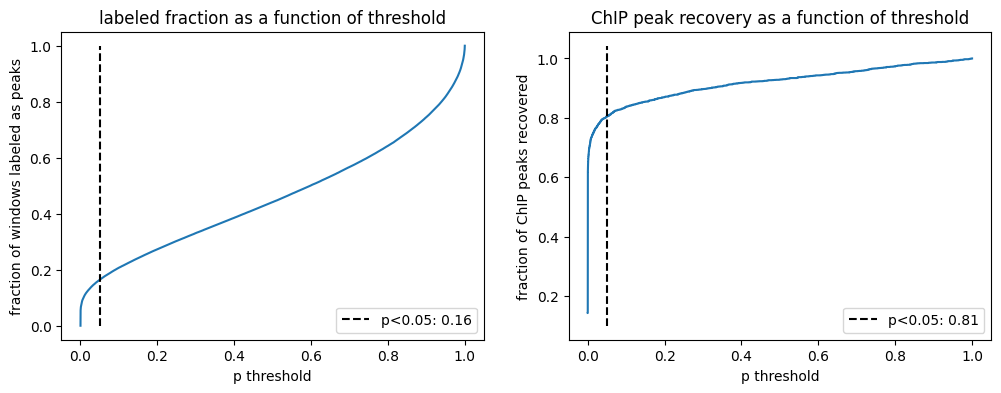

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(labeled_stats_df["prob"], labeled_stats_df["hit_fraction"])
y_min, y_max = plt.ylim()
axs[0].vlines(x=threshold, ymin=y_min, ymax=y_max, color="k", linestyle="--", label=f"p<{threshold}: {threshold_n_hits / len(labeled_stats_df):.2}")
axs[0].set_xlabel("p threshold")
axs[0].set_ylabel("fraction of windows labeled as peaks")
axs[0].set_title("labeled fraction as a function of threshold")
axs[0].legend(loc="lower right")

axs[1].plot(labeled_stats_df["prob"], labeled_stats_df["ChIP Recovery Fraction"])
y_min, y_max = plt.ylim()
axs[1].vlines(x=threshold, ymin=y_min, ymax=y_max, color="k", linestyle="--", label=f"p<{threshold}: {threshold_row['ChIP Recovery Fraction']:.2}")
axs[1].set_xlabel("p threshold")
axs[1].set_ylabel("fraction of ChIP peaks recovered")
axs[1].set_title("ChIP peak recovery as a function of threshold")
axs[1].legend(loc="lower right")
plt.show()

# Rudimentary peak calling take 2

In [1]:
from pathlib import Path
import subprocess

import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tqdm import tqdm
from matplotlib.colors import LogNorm

import config

In [2]:
modkit_exe = Path("/Users/jeremy/devspace/cargo_local/bin/modkit")

# Starting with chr11 as a test (the pileup for the browser happens to be all of chr11)
pileup_file = config.processed_data_dir / "pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.browser" / "pileup.sorted.bed.gz"
ctcf_chip_seq_file = Path("/Users/jeremy/devspace/multimodal-dimelo/review_data/chr11_ctcf_chip_peaks.bed")

output_dir = config.working_dir / "review_data" / "peak_calling"

genome_index_file = output_dir / "chr11.fai"


# parallel arrays
window_sizes = [250, 500, 1000]
step_sizes = window_sizes

threshold = 0.05

## Generate windows

In [3]:
window_files = []
for window_size, step_size in zip(window_sizes, step_sizes):
    window_file = genome_index_file.with_suffix(f".w{window_size}.s{step_size}.bed")
    subprocess.run(f"bedtools makewindows -g {genome_index_file} -w {window_size} -s {step_size} > {window_file}", shell=True)
    window_files.append(window_file)

## Definitions

In [4]:
def modkit_stats(window_file: Path) -> pd.DataFrame:
    modkit_stats_file = output_dir / f"modkit_stats.{window_file.stem}.tsv"
    # TODO: consider handling the file exists errors gracefully or something
    subprocess.run(f"{modkit_exe} stats {pileup_file} --regions {window_file} -o {modkit_stats_file}", shell=True)
    return pd.read_csv(modkit_stats_file, sep="\t")[["#chrom", "start", "end", "count_a", "count_valid_a"]]

In [5]:
def window_probabilities(modkit_stats_df: pd.DataFrame, distribution: str) -> pd.Series:
    match distribution:
        case "betabinom":
            alpha = np.round(modkit_stats_df["count_a"].mean())
            beta = np.round(modkit_stats_df["count_valid_a"].mean() - alpha)
            return modkit_stats_df.apply(lambda row: 1 - stats.betabinom.cdf(k=row["count_a"], n=row["count_valid_a"], a=alpha, b=beta), axis="columns")
        case "betabinom_mom":
            m1 = modkit_stats_df["count_a"].mean()
            m2 = modkit_stats_df["count_a"].pow(2).mean()
            n = modkit_stats_df["count_valid_a"]
            a_hat = ((n*m1) - m2) / ((n * ((m2/m1) - m1 - 1)) + m1)
            b_hat = ((n - m1) * (n - (m2/m1))) / ((n * ((m2/m1) - m1 - 1)) + m1)
            # TODO: this is a bandaid
            # replace NaNs with 0 to match scipy behavior for when there are 0 trials
            return modkit_stats_df.assign(a_hat=a_hat, b_hat=b_hat).apply(lambda row: 1 - stats.betabinom.cdf(k=row["count_a"], n=row["count_valid_a"], a=row["a_hat"], b=row["b_hat"]), axis="columns").fillna(0)
        case "binom":
            p = modkit_stats_df["count_a"].sum() / modkit_stats_df["count_valid_a"].sum()
            return modkit_stats_df.apply(lambda row: 1 - stats.binom.cdf(k=row["count_a"], n=row["count_valid_a"], p=p), axis="columns")
        case _:
            raise ValueError("Unknown distribution type")

In [6]:
def window_labels(window_file: Path, chip_peak_file: Path) -> pd.DataFrame:
    label_file = output_dir / f"window_labels.{window_file.stem}.tsv"
    # TODO: consider not running if the file already exists
    subprocess.run(f"bedtools intersect -a {window_file} -b {chip_peak_file} -C | awk -F '\t' 'BEGIN {{OFS = FS}} $4 > 1 {{ $4 = 1 }} {{print}}' > {label_file}", shell=True)
    return pd.read_csv(label_file, sep="\t", header=None, names=["#chrom", "start", "end", "label"])

In [7]:
def window_peak_assignments(window_file: Path, chip_peak_file: Path) -> pd.DataFrame:
    window_chip_assignment_file = output_dir / f"window_chip_assignments.{window_file.stem}.tsv"
    # TODO: consider not running if the file already exists
    subprocess.run(f"bedtools intersect -a {window_file} -b {chip_peak_file} -wao | cut -f 1-6 > {window_chip_assignment_file}", shell=True)
    
    window_chip_assignment_df = pd.read_csv(window_chip_assignment_file, sep="\t", header=None, names=["#chrom", "start", "end", "chip_chr", "chip_start", "chip_end"])
    # Turn ChIP peak locations into unique identifiers
    window_chip_assignment_df["chip_ids"] = window_chip_assignment_df[["chip_chr", "chip_start", "chip_end"]].astype("str").agg(":".join, axis="columns")
    # Drop windows that have no assigned peaks; group peak assignments together for each genomic window
    window_chip_assignment_df = window_chip_assignment_df[["#chrom", "start", "end", "chip_ids"]].query("chip_ids != '.:-1:-1'").groupby(["#chrom", "start", "end"]).agg({"chip_ids": set}).reset_index()
    return window_chip_assignment_df

In [8]:
def labeled_stats(label_df: pd.DataFrame, modkit_stats_df: pd.DataFrame, window_chip_assignment_df: pd.DataFrame) -> pd.DataFrame:
    # TODO: Rename this method and consider splitting it up even more
    ### Calculate outcomes
    positives = label_df["label"].sum()
    negatives = len(label_df) - positives

    labeled_stats_df = pd.merge(modkit_stats_df, label_df, on=["#chrom", "start", "end"]).sort_values("prob").reset_index(drop=True)

    # These are surprisingly effective and efficient; are they idiomatic?
    # How they work: Because it is sorted by probability, 1. count how many positive labels have been observed up until each row, 2. replace this count with the maximum count observed over all rows with that probability
    labeled_stats_df["TP"] = labeled_stats_df["label"].expanding().sum()
    labeled_stats_df["TP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["TP"])

    labeled_stats_df["FP"] = (labeled_stats_df["label"] == 0).expanding().sum()
    labeled_stats_df["FP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["FP"])

    labeled_stats_df["FN"] = positives - labeled_stats_df["TP"]
    labeled_stats_df["TN"] = negatives - labeled_stats_df["FP"]

    labeled_stats_df["TPR"] = labeled_stats_df["TP"] / positives
    labeled_stats_df["FPR"] = labeled_stats_df["FP"] / negatives

    labeled_stats_df["precision"] = labeled_stats_df["TP"] / (labeled_stats_df["TP"] + labeled_stats_df["FP"])
    
    # TODO: Rename this column.
    # Contains the fraction of the rows that would be returned as a hit if the probability for that row was the threshold
    labeled_stats_df["hit_fraction"] = (labeled_stats_df["prob"].rank(method="min") - 1) / len(labeled_stats_df)

    ### Calculate ChIP recovery
    # TODO: assert that this is the correct number based off of the count from the original ChIP file
    n_chip_hits = window_chip_assignment_df["chip_ids"].explode().nunique()
    labeled_stats_df = pd.merge(labeled_stats_df, window_chip_assignment_df, how="left", on=["#chrom", "start", "end"])
    captured_set = set()
    chip_hits = []
    for chip_id_set in labeled_stats_df["chip_ids"]:
        if chip_id_set is not np.nan:
            captured_set = captured_set.union(chip_id_set)
        chip_hits.append(len(captured_set))
    labeled_stats_df["ChIP Recovery Fraction"] = np.array(chip_hits) / n_chip_hits
    # replace this count with the maximum count observed over all rows with that probability
    labeled_stats_df["ChIP Recovery Fraction"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["ChIP Recovery Fraction"])

    return labeled_stats_df

In [9]:
def roc_plot(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    auc = np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"])

    plt.figure(figsize=(6,6))
    plt.plot(labeled_stats_df["FPR"], labeled_stats_df["TPR"], label=f"AUC: {auc:.2}")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        plt.vlines(x=threshold_row["FPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'FPR: {threshold_row["FPR"]:.2}')
        plt.hlines(y=threshold_row["TPR"], xmin=0, xmax=1, color="r", linestyle="--", label=f'TPR: {threshold_row["TPR"]:.2}')
        plt.title(f"ROC: p<{threshold}")
    else:
        plt.title("ROC")
    plt.legend(loc="lower right")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.show()
    plt.close()

In [10]:
def precision_recall_plot(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    # TODO: This overlaps greatly with ROC plot and also should probably be on the same axes
    auc = np.trapezoid(labeled_stats_df["precision"], labeled_stats_df["TPR"])

    plt.figure(figsize=(6,6))
    plt.plot(labeled_stats_df["TPR"], labeled_stats_df["precision"], label=f"AUC: {auc:.2}")
    baseline = labeled_stats_df["label"].sum() / len(labeled_stats_df)
    plt.hlines(y=baseline, xmin=0, xmax=1, label="baseline", color="grey", linestyle="-.")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        plt.vlines(x=threshold_row["TPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'recall: {threshold_row["TPR"]:.2}')
        plt.hlines(y=threshold_row["precision"], xmin=0, xmax=1, color="r", linestyle="--", label=f'precision: {threshold_row["precision"]:.2}')
        plt.title(f"precision-recall curve: p<{threshold}")
    else:
        plt.title("precision-recall curve")
    plt.legend(loc="best")
    plt.xlabel("recall")
    plt.ylabel("precision")
    plt.show()
    plt.close()

In [11]:
def confusion_matrix_plot(labeled_stats_df: pd.DataFrame, threshold: float):
    threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
    cm = np.reshape(threshold_row[["TP", "FN", "FP", "TN"]], (2,2)).astype("int")

    ax = sns.heatmap(cm, annot=True, fmt="", xticklabels=["True", "False"], yticklabels=["True", "False"], norm=LogNorm())
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    ax.set_title(f"Confusion matrix: p<{threshold}")
    plt.show()
    plt.close()

In [12]:
def peak_label_plots(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    _, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].plot(labeled_stats_df["prob"], labeled_stats_df["hit_fraction"])
    
    axs[0].set_xlabel("p threshold")
    axs[0].set_ylabel("fraction of windows labeled as peaks")
    axs[0].set_title("labeled fraction as a function of threshold")

    axs[1].plot(labeled_stats_df["prob"], labeled_stats_df["ChIP Recovery Fraction"])
    axs[1].set_xlabel("p threshold")
    axs[1].set_ylabel("fraction of ChIP peaks recovered")
    axs[1].set_title("ChIP peak recovery as a function of threshold")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        threshold_n_hits = threshold_row.name

        axs[0].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_n_hits / len(labeled_stats_df):.2}")
        axs[0].legend(loc="lower right")

        axs[1].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_row['ChIP Recovery Fraction']:.2}")
        axs[1].legend(loc="lower right")
    
    plt.show()
    plt.close()

In [13]:
result_dfs = []
for window_file in window_files:
    modkit_stats_df = modkit_stats(window_file)
    # TODO: consider reintroducing the distribution plot with alpha on it
    # TODO: don't like reliance on column names
    modkit_stats_df["prob"] = window_probabilities(modkit_stats_df, "betabinom_mom")
    label_df = window_labels(window_file, ctcf_chip_seq_file)
    window_chip_assignment_df = window_peak_assignments(window_file, ctcf_chip_seq_file)
    labeled_stats_df = labeled_stats(label_df, modkit_stats_df, window_chip_assignment_df)
    result_dfs.append(labeled_stats_df)

> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)


250


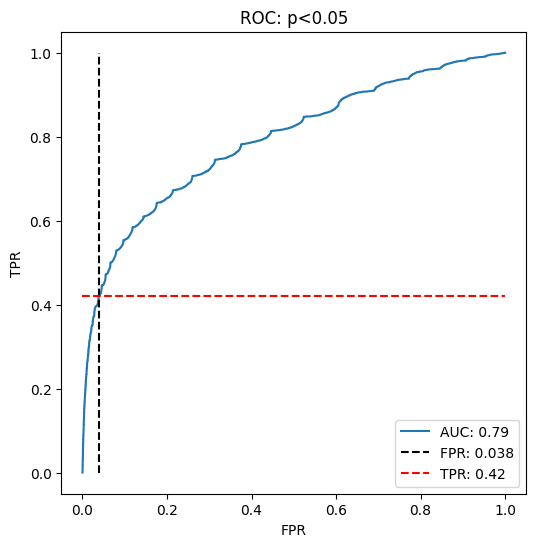

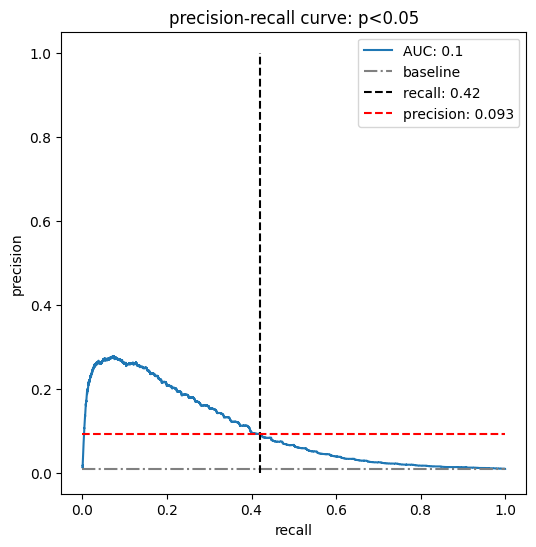

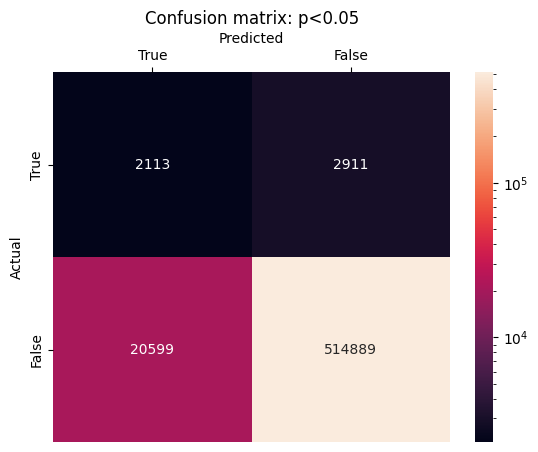

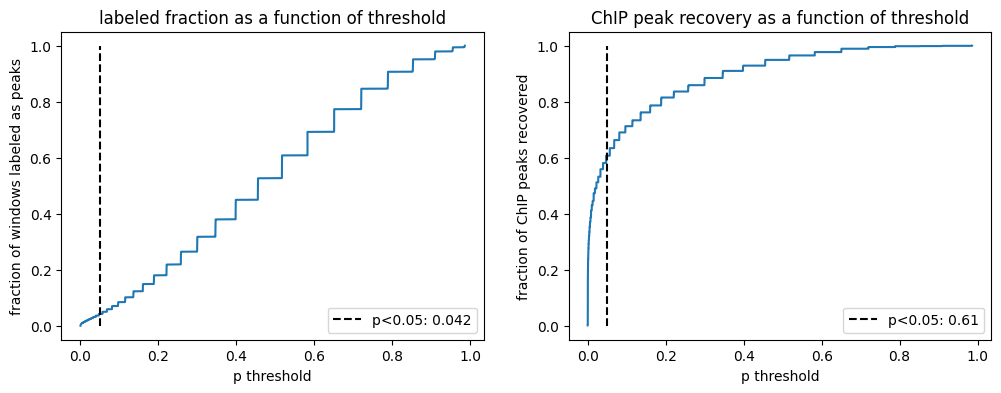

500


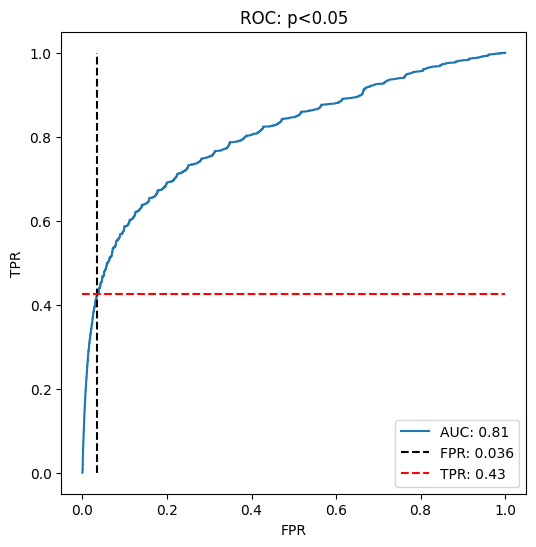

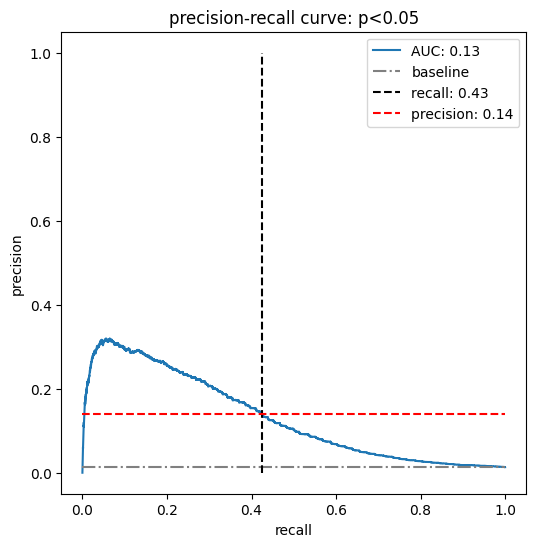

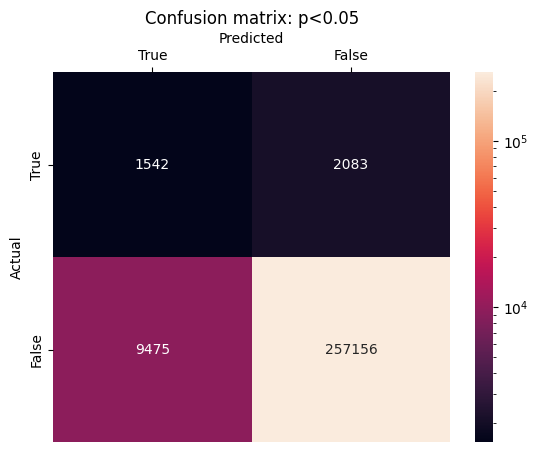

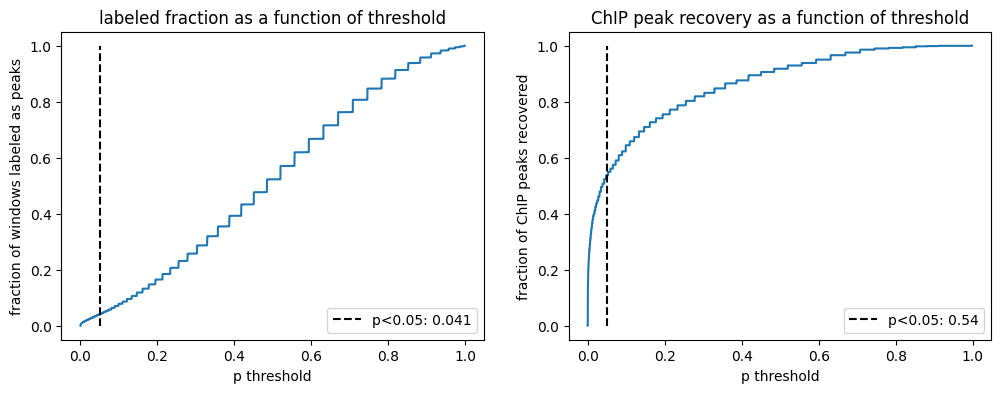

1000


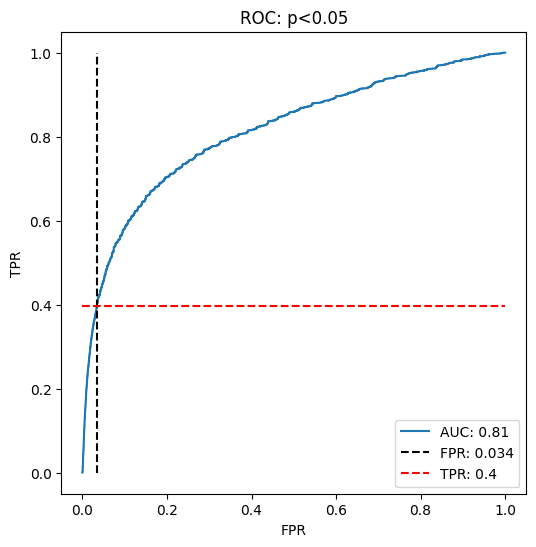

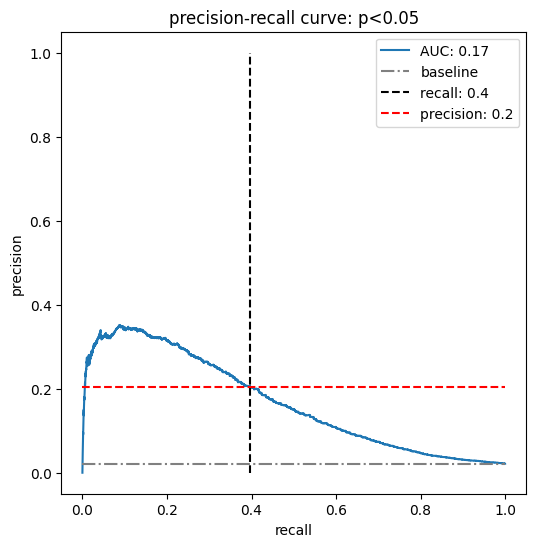

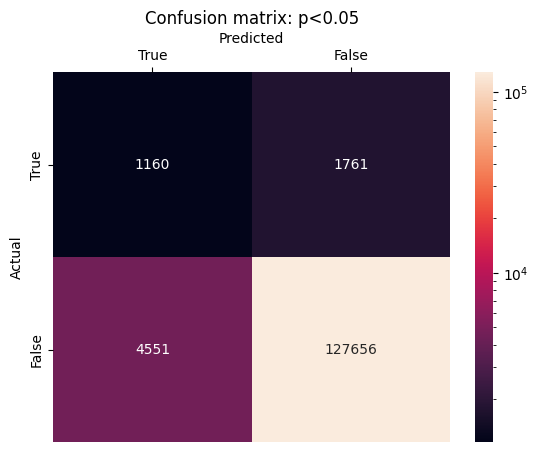

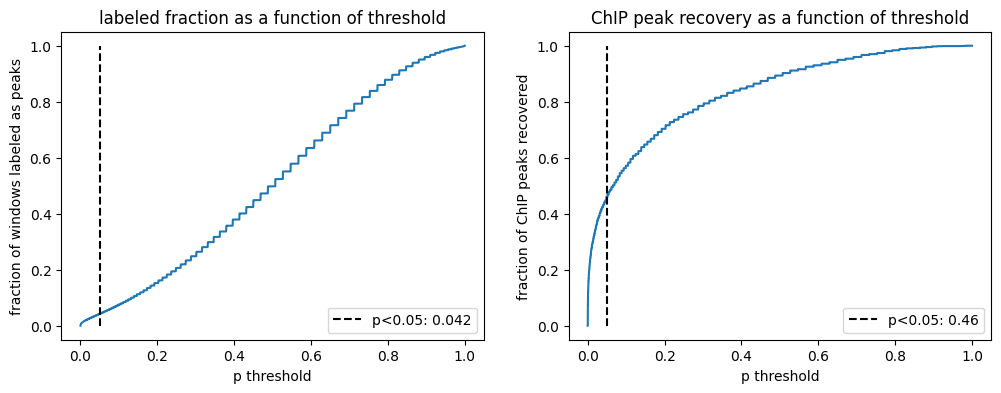

In [93]:
threshold = 0.05
for window_size, labeled_stats_df in zip(window_sizes, result_dfs):
    print(window_size)
    roc_plot(labeled_stats_df, threshold=threshold)
    precision_recall_plot(labeled_stats_df, threshold=threshold)
    confusion_matrix_plot(labeled_stats_df, threshold=threshold)
    peak_label_plots(labeled_stats_df, threshold=threshold)

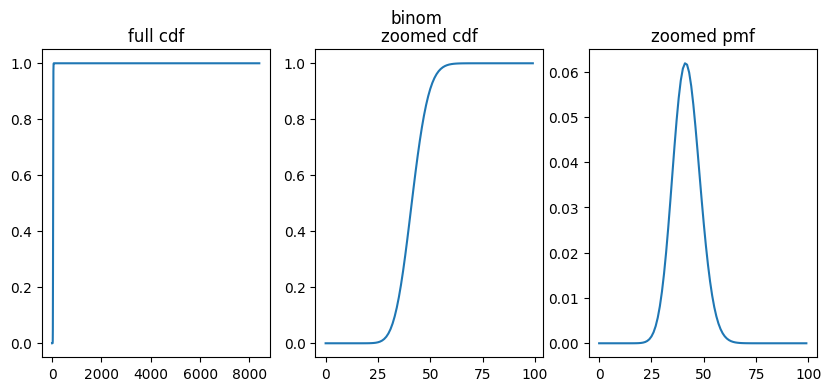

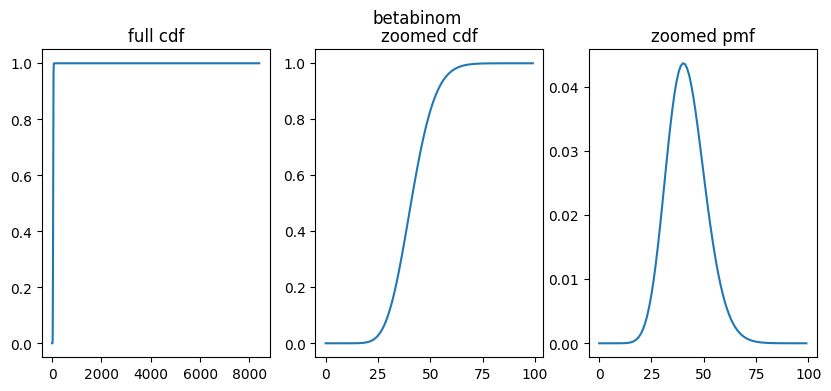

In [32]:
alpha = 40
beta = 8000

# n = int(alpha + beta)
n = 8400

x = np.linspace(0, n, n+1)
cdf_binom = stats.binom.cdf(x, n, alpha/(alpha+beta))
pmf_binom = stats.binom.pmf(x, n, alpha/(alpha+beta))
cdf_betabinom = stats.betabinom.cdf(x, n, alpha, beta)
pmf_betabinom = stats.betabinom.pmf(x, n, alpha, beta)

_, axs = plt.subplots(1, 3, figsize=(10,4))
axs[0].plot(x, cdf_binom)
axs[0].set_title("full cdf")
axs[1].plot(x[:100], cdf_binom[:100])
axs[1].set_title("zoomed cdf")
axs[2].plot(x[:100], pmf_binom[:100])
axs[2].set_title("zoomed pmf")
plt.suptitle("binom")
plt.show()

_, axs = plt.subplots(1, 3, figsize=(10,4))
axs[0].plot(x, cdf_betabinom)
axs[0].set_title("full cdf")
axs[1].plot(x[:100], cdf_betabinom[:100])
axs[1].set_title("zoomed cdf")
axs[2].plot(x[:100], pmf_betabinom[:100])
axs[2].set_title("zoomed pmf")
plt.suptitle("betabinom")
plt.show()

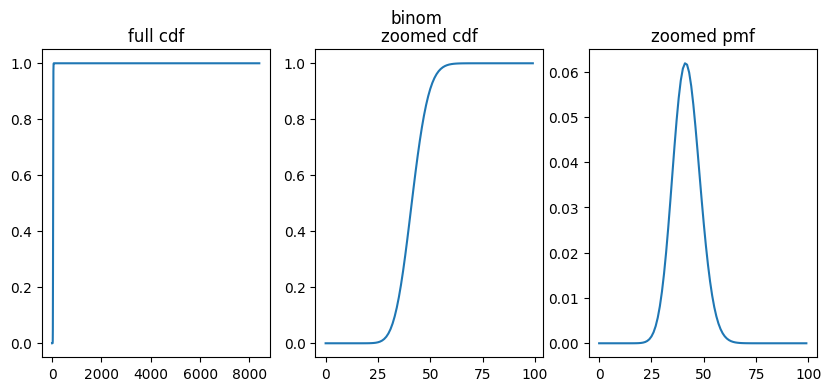

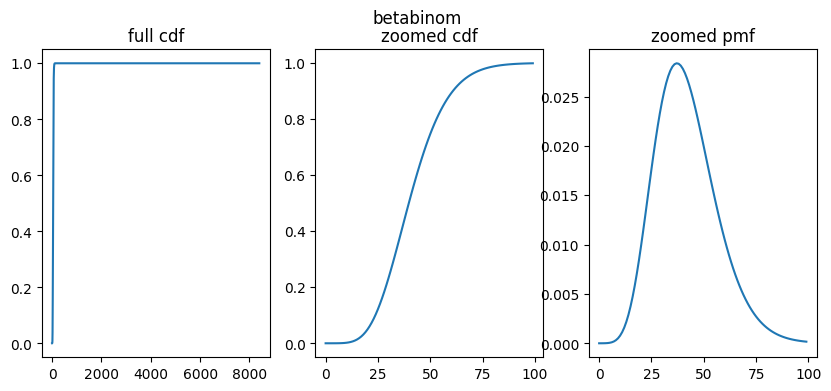

In [33]:
alpha = 10
beta = 2000

# n = int(alpha + beta)
n = 8400

x = np.linspace(0, n, n+1)
cdf_binom = stats.binom.cdf(x, n, alpha/(alpha+beta))
pmf_binom = stats.binom.pmf(x, n, alpha/(alpha+beta))
cdf_betabinom = stats.betabinom.cdf(x, n, alpha, beta)
pmf_betabinom = stats.betabinom.pmf(x, n, alpha, beta)

_, axs = plt.subplots(1, 3, figsize=(10,4))
axs[0].plot(x, cdf_binom)
axs[0].set_title("full cdf")
axs[1].plot(x[:100], cdf_binom[:100])
axs[1].set_title("zoomed cdf")
axs[2].plot(x[:100], pmf_binom[:100])
axs[2].set_title("zoomed pmf")
plt.suptitle("binom")
plt.show()

_, axs = plt.subplots(1, 3, figsize=(10,4))
axs[0].plot(x, cdf_betabinom)
axs[0].set_title("full cdf")
axs[1].plot(x[:100], cdf_betabinom[:100])
axs[1].set_title("zoomed cdf")
axs[2].plot(x[:100], pmf_betabinom[:100])
axs[2].set_title("zoomed pmf")
plt.suptitle("betabinom")
plt.show()

3.835509854027073 792.9486714662678


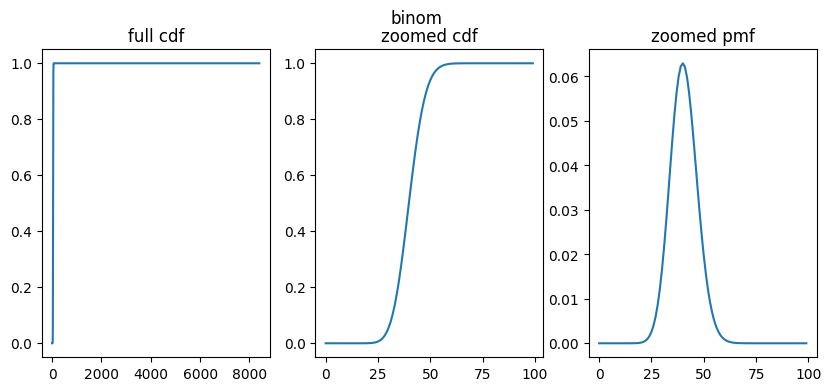

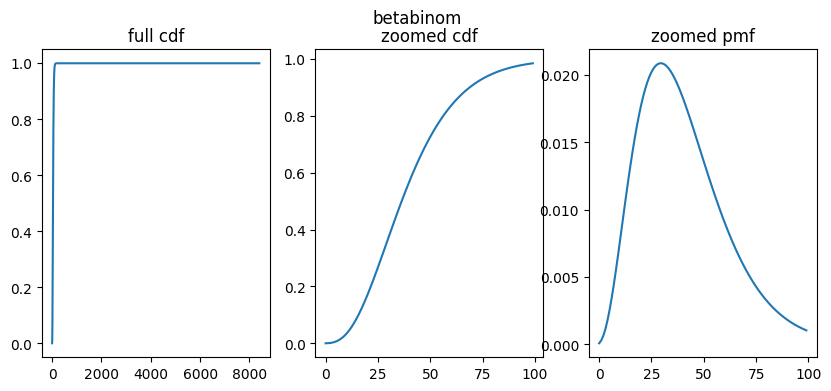

In [58]:
m1 = labeled_stats_df["count_a"].mean()
m2 = labeled_stats_df["count_a"].pow(2).mean()

n = 8400
alpha = ((n*m1) - m2) / ((n * ((m2/m1) - m1 - 1)) + m1)
beta = ((n - m1) * (n - (m2/m1))) / ((n * ((m2/m1) - m1 - 1)) + m1)
print(alpha, beta)

x = np.linspace(0, n, n+1)
cdf_binom = stats.binom.cdf(x, n, alpha/(alpha+beta))
pmf_binom = stats.binom.pmf(x, n, alpha/(alpha+beta))
cdf_betabinom = stats.betabinom.cdf(x, n, alpha, beta)
pmf_betabinom = stats.betabinom.pmf(x, n, alpha, beta)

_, axs = plt.subplots(1, 3, figsize=(10,4))
axs[0].plot(x, cdf_binom)
axs[0].set_title("full cdf")
axs[1].plot(x[:100], cdf_binom[:100])
axs[1].set_title("zoomed cdf")
axs[2].plot(x[:100], pmf_binom[:100])
axs[2].set_title("zoomed pmf")
plt.suptitle("binom")
plt.show()

_, axs = plt.subplots(1, 3, figsize=(10,4))
axs[0].plot(x, cdf_betabinom)
axs[0].set_title("full cdf")
axs[1].plot(x[:100], cdf_betabinom[:100])
axs[1].set_title("zoomed cdf")
axs[2].plot(x[:100], pmf_betabinom[:100])
axs[2].set_title("zoomed pmf")
plt.suptitle("betabinom")
plt.show()

# Rudimentary peak calling take 3

In [1]:
from pathlib import Path
import subprocess
from collections import defaultdict
from sys import float_info

import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LogNorm

import config

In [2]:
modkit_exe = Path("/Users/jeremy/devspace/cargo_local/bin/modkit")

# Starting with chr11 as a test (the pileup for the browser happens to be all of chr11)
pileup_file = config.processed_data_dir / "pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.browser" / "pileup.sorted.bed.gz"
ctcf_chip_seq_file = Path("/Users/jeremy/devspace/multimodal-dimelo/review_data/chr11_ctcf_chip_peaks.bed")

output_dir = config.working_dir / "review_data" / "peak_calling"

genome_index_file = output_dir / "chr11.fai"


# parallel arrays
window_sizes = [250, 500, 1000]
step_sizes = window_sizes

threshold = 0.05

## Generate windows

In [3]:
window_files = []
for window_size, step_size in zip(window_sizes, step_sizes):
    window_file = genome_index_file.with_suffix(f".w{window_size}.s{step_size}.bed")
    if not window_file.exists():
        subprocess.run(f"bedtools makewindows -g {genome_index_file} -w {window_size} -s {step_size} > {window_file}", shell=True)
    window_files.append(window_file)

## Fitting a beta by hand as a proof of concept

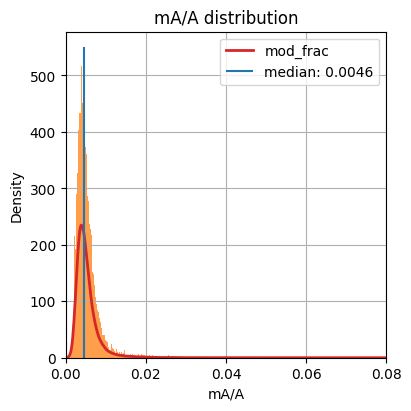

In [261]:
plt.figure(figsize=(4,4), layout="constrained")
modkit_stats_df["mod_frac"].hist(bins=5000, color="tab:orange", alpha=0.75)
modkit_stats_df["mod_frac"].plot.kde(color="tab:red", lw=2)
plt.vlines(modkit_stats_df["mod_frac"].median(), 0, 550, label=f'median: {modkit_stats_df["mod_frac"].median():.2}')
plt.legend()
plt.xlim(0, 0.08)
plt.grid()
plt.xlabel("mA/A")
plt.title("mA/A distribution")
plt.show()

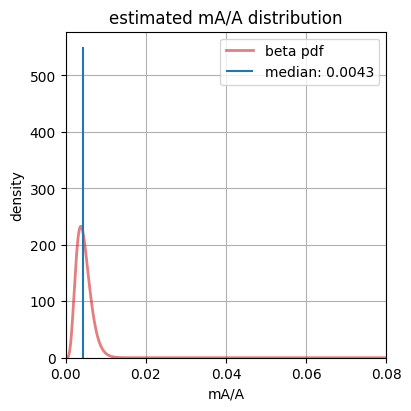

In [263]:
plt.figure(figsize=(4,4), layout="constrained")
a = 6
b = 1320
hand_fit_beta = stats.beta(a, b)
x = np.linspace(0, 0.08, 500)
plt.plot(x, hand_fit_beta.pdf(x), color="tab:red", alpha=0.6, label='beta pdf', lw=2)
plt.vlines(hand_fit_beta.median(), 0, 550, label=f"median: {hand_fit_beta.median():.2}")
plt.legend()
plt.xlim(0, 0.08)
plt.ylim((0, None))
plt.grid()
plt.xlabel("mA/A")
plt.ylabel("density")
plt.title("estimated mA/A distribution")
plt.show()

This wound up being basically the same as the one I got before using an average window to set alpha/beta.

Plotting distributions for comparison

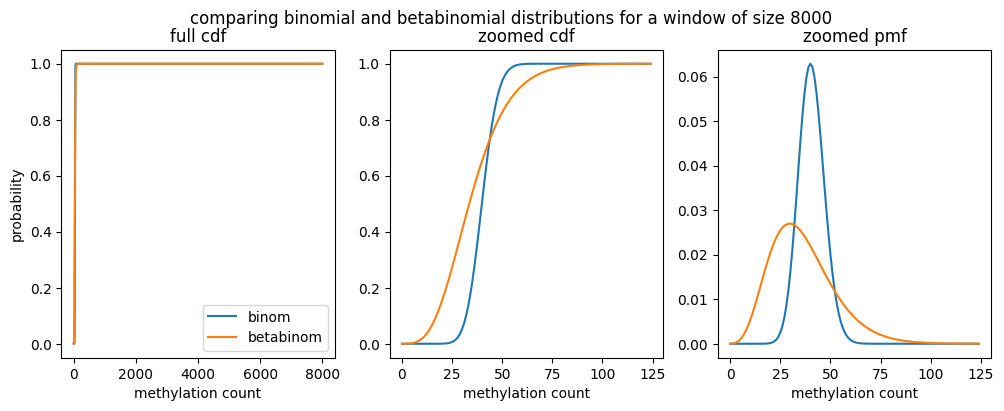

In [ ]:
n = 8000
p = modkit_stats_df["count_a"].sum() / modkit_stats_df["count_valid_a"].sum()
zoom_level = 125

x = np.linspace(0, n, n+1)
cdf_binom = stats.binom.cdf(x, n, p)
pmf_binom = stats.binom.pmf(x, n, p)
cdf_betabinom = stats.betabinom.cdf(x, n, a, b)
pmf_betabinom = stats.betabinom.pmf(x, n, a, b)

_, axs = plt.subplots(1, 3, figsize=(12,4))
axs[0].plot(x, cdf_binom, label="binom")
axs[0].plot(x, cdf_betabinom, label="betabinom")
axs[0].set_title("full cdf")
axs[0].legend()
axs[1].plot(x[:zoom_level], cdf_binom[:zoom_level])
axs[1].plot(x[:zoom_level], cdf_betabinom[:zoom_level])
axs[1].set_title("zoomed cdf")
axs[2].plot(x[:zoom_level], pmf_binom[:zoom_level])
axs[2].plot(x[:zoom_level], pmf_betabinom[:zoom_level])
axs[2].set_title("zoomed pmf")
for ax in axs:
    ax.set_xlabel("methylation count")
axs[0].set_ylabel("probability")
plt.suptitle(f"comparing binomial and betabinomial distributions for a window of size {n}")
plt.show()

Testing fitting a beta

In [7]:
modkit_stats_df = modkit_stats(window_files[2])

> Error! File exists (os error 17)


In [41]:
test = stats.beta.fit(modkit_stats_df["mod_frac"][modkit_stats_df["mod_frac"].between(0, 1, inclusive="neither")], floc=0, fscale=1)

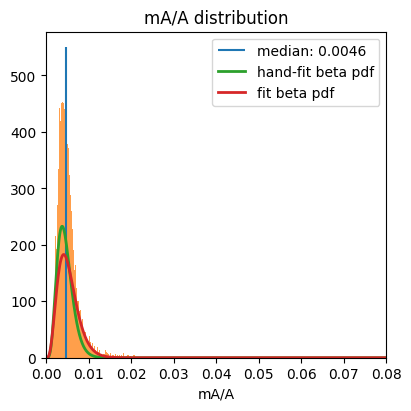

In [51]:
plt.figure(figsize=(4,4), layout="constrained")
modkit_stats_df["mod_frac"].hist(bins=5000, color="tab:orange", alpha=0.75)
# modkit_stats_df["mod_frac"].plot.kde(color="tab:red", lw=2)
plt.vlines(modkit_stats_df["mod_frac"].median(), 0, 550, label=f'median: {modkit_stats_df["mod_frac"].median():.2}')
a = 6
b = 1320
hand_fit_beta = stats.beta(a, b)
x = np.linspace(0, 0.08, 500)
plt.plot(x, hand_fit_beta.pdf(x), color="tab:green", label='hand-fit beta pdf', lw=2)
plt.plot(x, stats.beta.pdf(x, *test), color="tab:red", label='fit beta pdf', lw=2)
plt.legend()
plt.xlim(0, 0.08)
plt.grid()
plt.xlabel("mA/A")
plt.title("mA/A distribution")
plt.show()

## Definitions

In [4]:
def modkit_stats(window_file: Path) -> pd.DataFrame:
    modkit_stats_file = output_dir / f"modkit_stats.{window_file.stem}.tsv"
    # TODO: consider handling the file exists errors gracefully or something
    subprocess.run(f"{modkit_exe} stats {pileup_file} --regions {window_file} -o {modkit_stats_file}", shell=True)
    df = pd.read_csv(modkit_stats_file, sep="\t")[["#chrom", "start", "end", "count_a", "count_valid_a"]]
    df["mod_frac"] = df["count_a"] / df["count_valid_a"]
    return df

In [252]:
def window_probabilities(modkit_stats_df: pd.DataFrame, distribution: str) -> pd.Series:
    match distribution:
        case "betabinom":
            # Using hand-fit parameters from above
            alpha = 6
            beta = 1320
            probs = modkit_stats_df.apply(lambda row: 1 - stats.betabinom.cdf(k=row["count_a"], n=row["count_valid_a"], a=alpha, b=beta), axis="columns")
        case "binom":
            p = modkit_stats_df["count_a"].sum() / modkit_stats_df["count_valid_a"].sum()
            probs = modkit_stats_df.apply(lambda row: 1 - stats.binom.cdf(k=row["count_a"], n=row["count_valid_a"], p=p), axis="columns")
        case _:
            raise ValueError("Unknown distribution type")
    
    # TODO: This is a hacky solution
    # Ensure there are no probabilities of 0
    return probs.replace(0, float_info.epsilon)

In [213]:
def window_labels(window_file: Path, chip_peak_file: Path) -> pd.DataFrame:
    label_file = output_dir / f"window_labels.{window_file.stem}.tsv"
    if not label_file.exists():
        subprocess.run(f"bedtools intersect -a {window_file} -b {chip_peak_file} -C | awk -F '\t' 'BEGIN {{OFS = FS}} $4 > 1 {{ $4 = 1 }} {{print}}' > {label_file}", shell=True)
    return pd.read_csv(label_file, sep="\t", header=None, names=["#chrom", "start", "end", "label"])

In [214]:
def window_peak_assignments(window_file: Path, chip_peak_file: Path) -> pd.DataFrame:
    window_chip_assignment_file = output_dir / f"window_chip_assignments.{window_file.stem}.tsv"
    if not window_chip_assignment_file.exists():
        subprocess.run(f"bedtools intersect -a {window_file} -b {chip_peak_file} -wao | cut -f 1-6 > {window_chip_assignment_file}", shell=True)
    
    window_chip_assignment_df = pd.read_csv(window_chip_assignment_file, sep="\t", header=None, names=["#chrom", "start", "end", "chip_chr", "chip_start", "chip_end"])
    # Turn ChIP peak locations into unique identifiers
    window_chip_assignment_df["chip_ids"] = window_chip_assignment_df[["chip_chr", "chip_start", "chip_end"]].astype("str").agg(":".join, axis="columns")
    # Drop windows that have no assigned peaks; group peak assignments together for each genomic window
    window_chip_assignment_df = window_chip_assignment_df[["#chrom", "start", "end", "chip_ids"]].query("chip_ids != '.:-1:-1'").groupby(["#chrom", "start", "end"]).agg({"chip_ids": set}).reset_index()
    return window_chip_assignment_df

In [215]:
def labeled_stats(label_df: pd.DataFrame, modkit_stats_df: pd.DataFrame, window_chip_assignment_df: pd.DataFrame) -> pd.DataFrame:
    # TODO: Rename this method and consider splitting it up even more
    ### Calculate outcomes
    positives = label_df["label"].sum()
    negatives = len(label_df) - positives

    labeled_stats_df = pd.merge(modkit_stats_df, label_df, on=["#chrom", "start", "end"]).sort_values("prob").reset_index(drop=True)

    # These are surprisingly effective and efficient; are they idiomatic?
    # How they work: Because it is sorted by probability, 1. count how many positive labels have been observed up until each row, 2. replace this count with the maximum count observed over all rows with that probability
    labeled_stats_df["TP"] = labeled_stats_df["label"].expanding().sum()
    labeled_stats_df["TP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["TP"])

    labeled_stats_df["FP"] = (labeled_stats_df["label"] == 0).expanding().sum()
    labeled_stats_df["FP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["FP"])

    labeled_stats_df["FN"] = positives - labeled_stats_df["TP"]
    labeled_stats_df["TN"] = negatives - labeled_stats_df["FP"]

    labeled_stats_df["TPR"] = labeled_stats_df["TP"] / positives
    labeled_stats_df["FPR"] = labeled_stats_df["FP"] / negatives

    labeled_stats_df["precision"] = labeled_stats_df["TP"] / (labeled_stats_df["TP"] + labeled_stats_df["FP"])
    
    # TODO: Rename this column.
    # Contains the fraction of the rows that would be returned as a hit if the probability for that row was the threshold
    labeled_stats_df["hit_fraction"] = (labeled_stats_df["prob"].rank(method="min") - 1) / len(labeled_stats_df)

    ### Calculate ChIP recovery
    # TODO: assert that this is the correct number based off of the count from the original ChIP file
    n_chip_hits = window_chip_assignment_df["chip_ids"].explode().nunique()
    labeled_stats_df = pd.merge(labeled_stats_df, window_chip_assignment_df, how="left", on=["#chrom", "start", "end"])
    captured_set = set()
    chip_hits = []
    for chip_id_set in labeled_stats_df["chip_ids"]:
        if chip_id_set is not np.nan:
            captured_set = captured_set.union(chip_id_set)
        chip_hits.append(len(captured_set))
    labeled_stats_df["ChIP Recovery Fraction"] = np.array(chip_hits) / n_chip_hits
    # replace this count with the maximum count observed over all rows with that probability
    labeled_stats_df["ChIP Recovery Fraction"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["ChIP Recovery Fraction"])

    return labeled_stats_df

In [238]:
def roc_prc_plot(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    roc_auc = np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"])
    prc_auc = np.trapezoid(labeled_stats_df["precision"], labeled_stats_df["TPR"])

    _, axs = plt.subplots(1, 2, layout="constrained", figsize=(8, 4))

    axs[0].plot(labeled_stats_df["FPR"], labeled_stats_df["TPR"], label=f"AUC: {roc_auc:.2}")
    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        axs[0].vlines(x=threshold_row["FPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'FPR: {threshold_row["FPR"]:.2}')
        axs[0].hlines(y=threshold_row["TPR"], xmin=0, xmax=1, color="r", linestyle="--", label=f'TPR: {threshold_row["TPR"]:.2}')
        axs[0].set_title(f"ROC: p<{threshold}")
    else:
        axs[0].set_title("ROC")
    axs[0].legend(loc="lower right")
    axs[0].set_xlabel("FPR")
    axs[0].set_ylabel("TPR")
    axs[0].set_box_aspect(1)

    axs[1].plot(labeled_stats_df["TPR"], labeled_stats_df["precision"], label=f"AUC: {prc_auc:.2}")
    baseline = labeled_stats_df["label"].sum() / len(labeled_stats_df)
    axs[1].hlines(y=baseline, xmin=0, xmax=1, label="baseline", color="grey", linestyle="-.")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        axs[1].vlines(x=threshold_row["TPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'recall: {threshold_row["TPR"]:.2}')
        axs[1].hlines(y=threshold_row["precision"], xmin=0, xmax=1, color="r", linestyle="--", label=f'precision: {threshold_row["precision"]:.2}')
        axs[1].set_title(f"precision-recall curve: p<{threshold}")
    else:
        axs[1].set_title("precision-recall curve")
    axs[1].legend(loc="best")
    axs[1].set_xlabel("recall")
    axs[1].set_ylabel("precision")
    axs[1].set_box_aspect(1)

    plt.show()
    plt.close()

In [218]:
def confusion_matrix_plot(labeled_stats_df: pd.DataFrame, threshold: float):
    threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
    cm = np.reshape(threshold_row[["TP", "FN", "FP", "TN"]], (2,2)).astype("int")

    ax = sns.heatmap(cm, annot=True, fmt="", xticklabels=["True", "False"], yticklabels=["True", "False"], norm=LogNorm())
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    ax.set_title(f"Confusion matrix: p<{threshold}")
    plt.show()
    plt.close()

In [241]:
def peak_label_plots(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    _, axs = plt.subplots(1, 2, layout="constrained", figsize=(8, 4))

    axs[0].plot(labeled_stats_df["prob"], labeled_stats_df["hit_fraction"])
    
    axs[0].set_xlabel("p threshold")
    axs[0].set_ylabel("fraction of windows labeled as peaks")
    axs[0].set_title("labeled fraction as a function of threshold")
    axs[0].set_box_aspect(1)

    axs[1].plot(labeled_stats_df["prob"], labeled_stats_df["ChIP Recovery Fraction"])
    axs[1].set_xlabel("p threshold")
    axs[1].set_ylabel("fraction of ChIP peaks recovered")
    axs[1].set_title("ChIP peak recovery as a function of threshold")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        threshold_n_hits = threshold_row.name

        axs[0].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_n_hits / len(labeled_stats_df):.2}")
        axs[0].legend(loc="lower right")

        axs[1].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_row['ChIP Recovery Fraction']:.2}")
        axs[1].legend(loc="lower right")
    axs[1].set_box_aspect(1)
   
    plt.show()
    plt.close()

## Running analysis

In [253]:
distribution_result_dfs = defaultdict(list)
for distribution in ["binom", "betabinom"]:
    for window_file in window_files:
        modkit_stats_df = modkit_stats(window_file)
        # TODO: don't like reliance on column names
        modkit_stats_df["prob"] = window_probabilities(modkit_stats_df, distribution)
        label_df = window_labels(window_file, ctcf_chip_seq_file)
        window_chip_assignment_df = window_peak_assignments(window_file, ctcf_chip_seq_file)
        labeled_stats_df = labeled_stats(label_df, modkit_stats_df, window_chip_assignment_df)
        distribution_result_dfs[distribution].append(labeled_stats_df)

> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)


## Plotting

binom 250


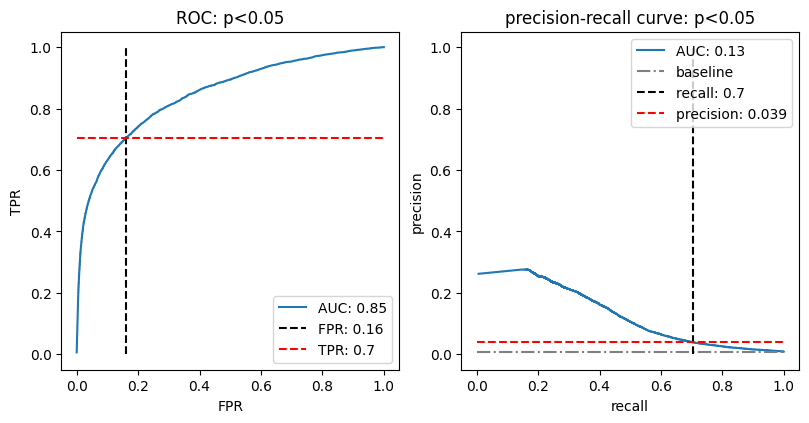

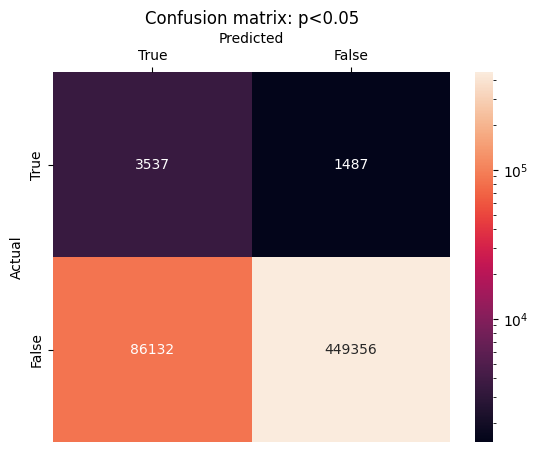

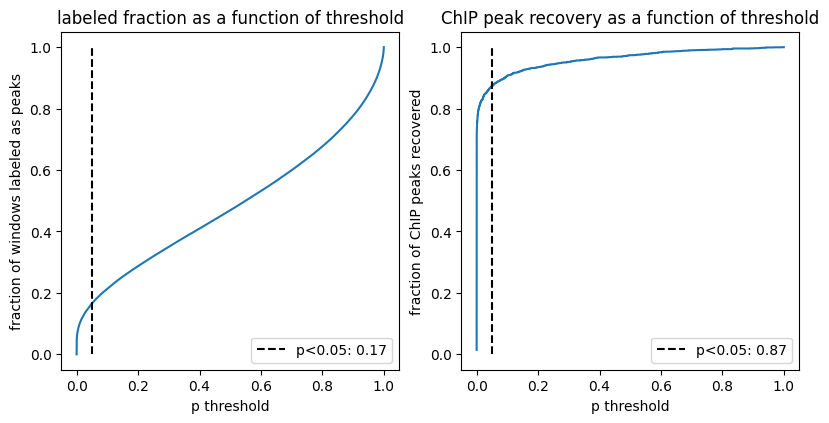

binom 500


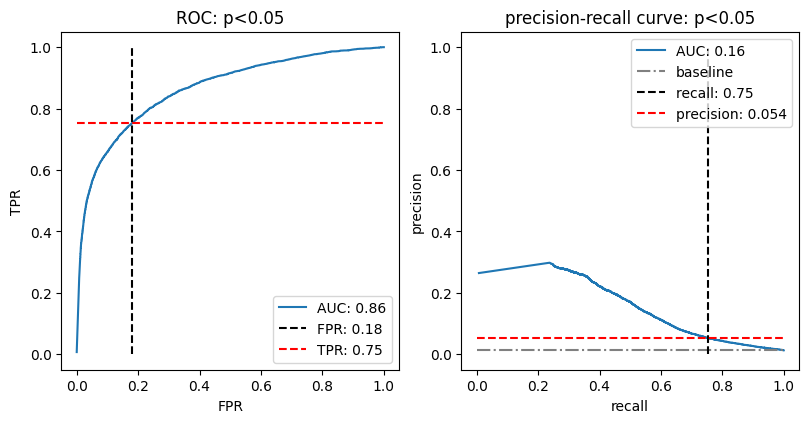

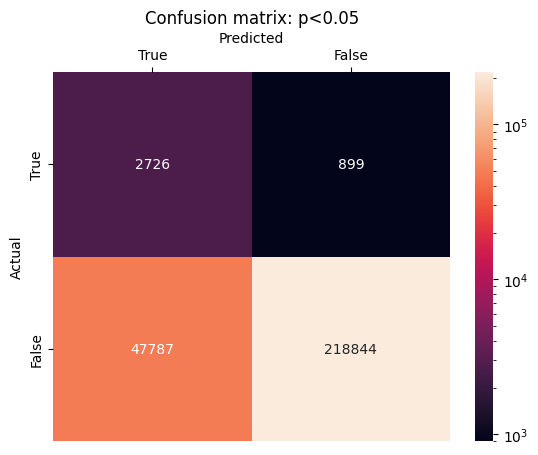

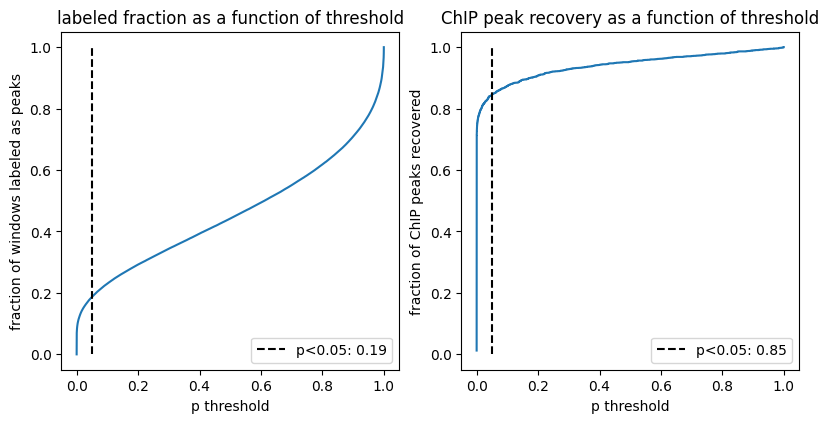

binom 1000


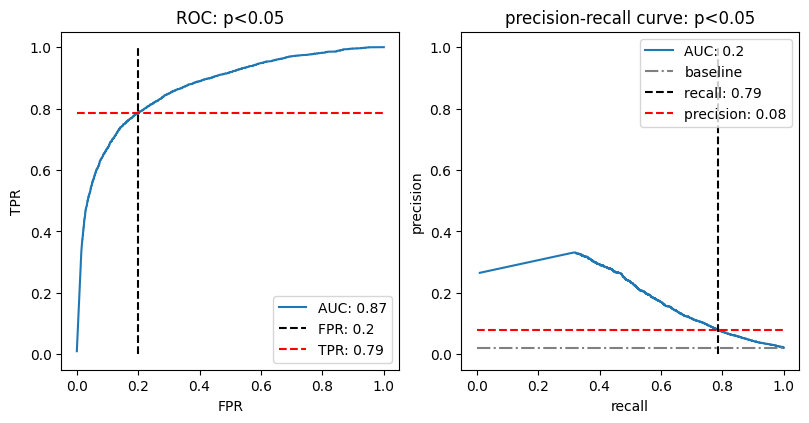

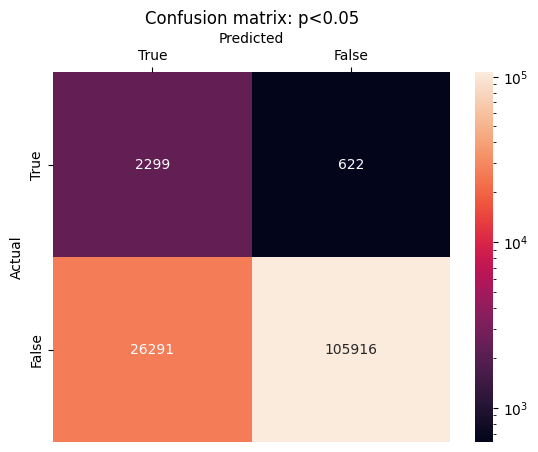

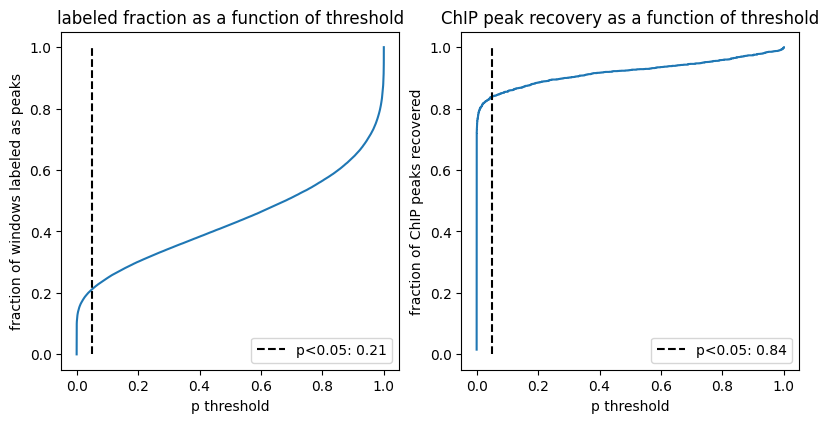

betabinom 250


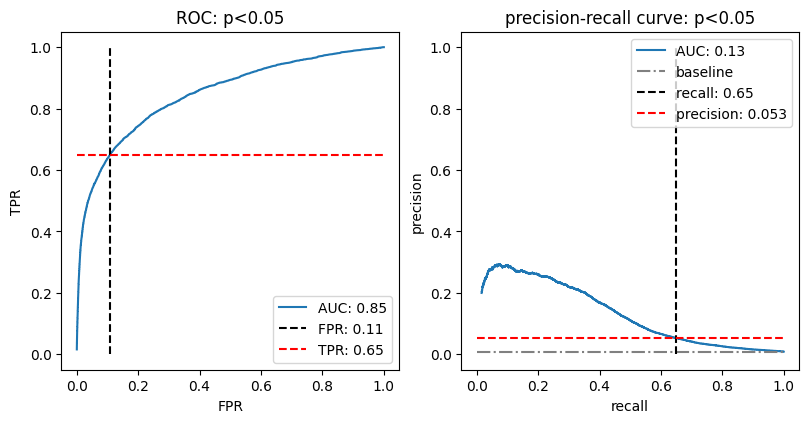

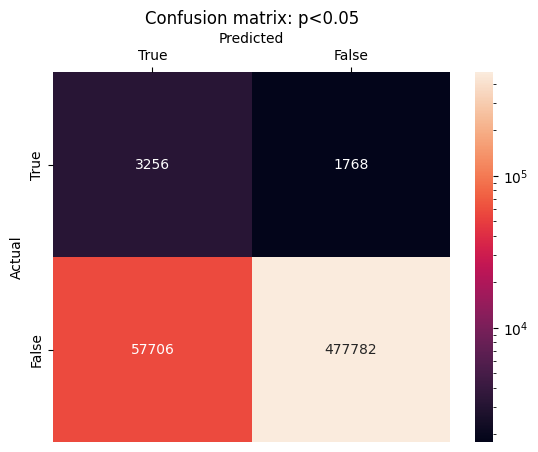

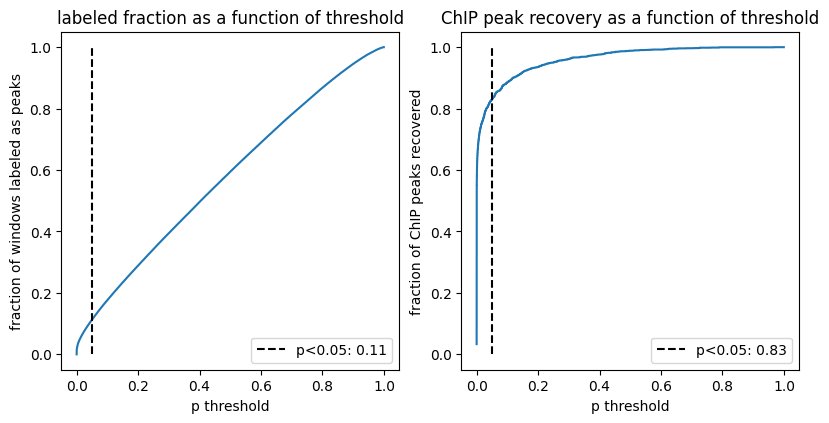

betabinom 500


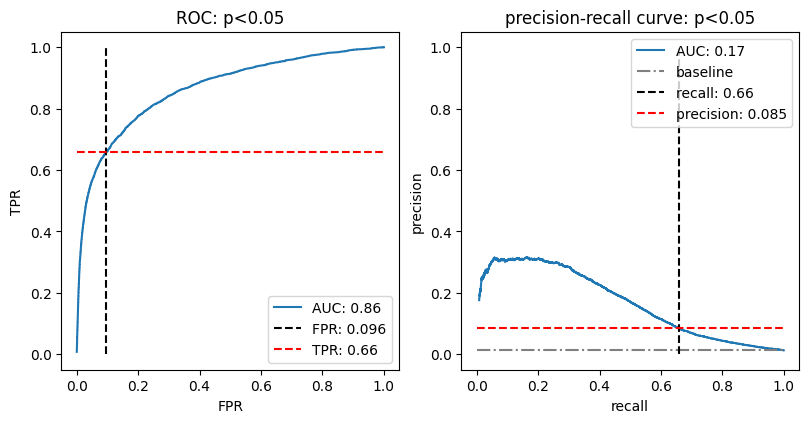

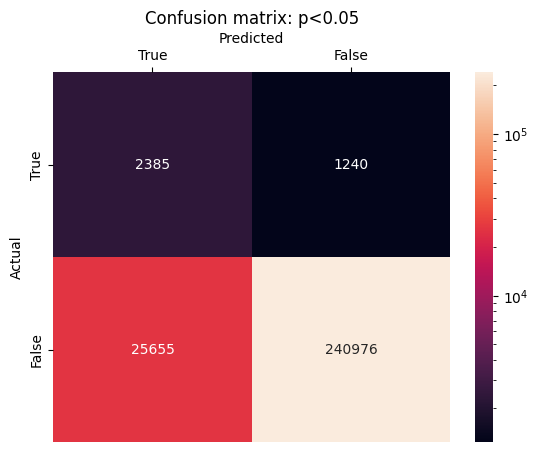

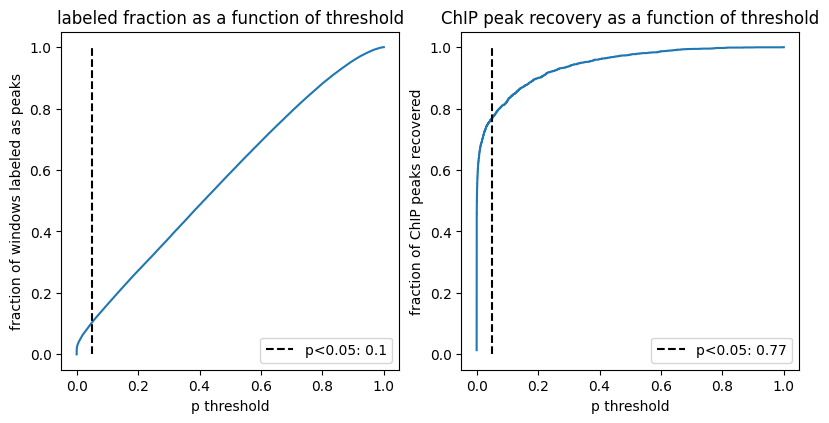

betabinom 1000


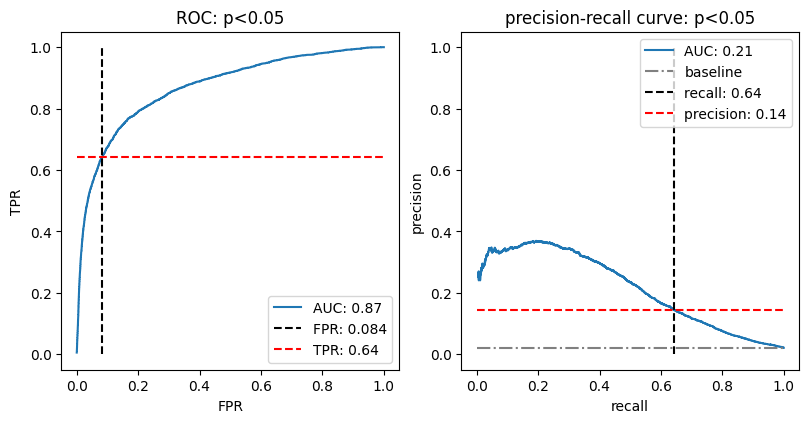

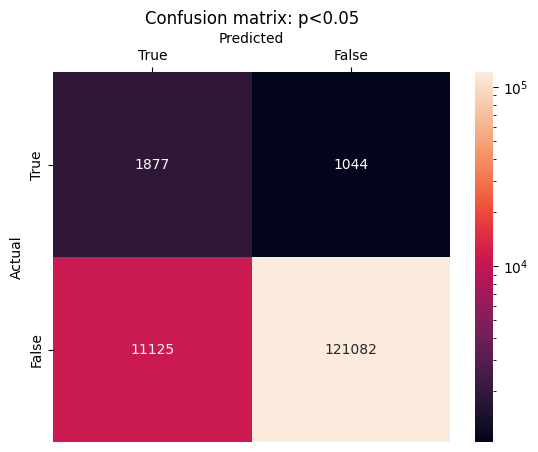

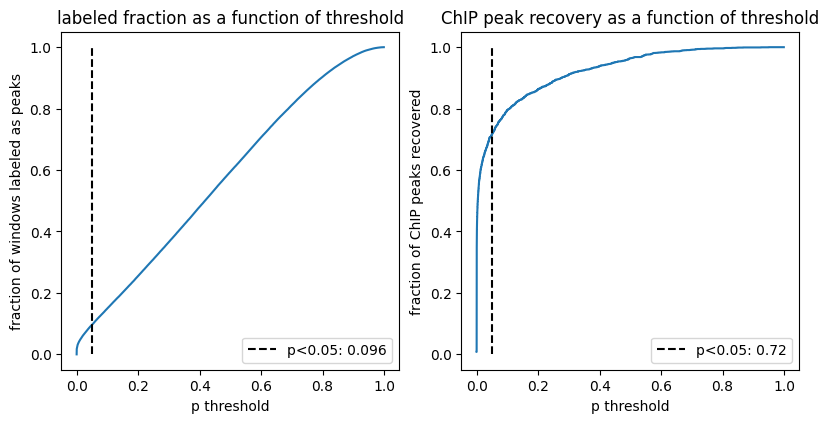

In [ ]:
threshold = 0.05

for distribution in ["binom", "betabinom"]:
    for window_size, labeled_stats_df in zip(window_sizes, distribution_result_dfs[distribution]):
        print(distribution, window_size)
        roc_prc_plot(labeled_stats_df, threshold=threshold)
        confusion_matrix_plot(labeled_stats_df, threshold=threshold)
        peak_label_plots(labeled_stats_df, threshold=threshold)

# Rudimentary peak calling take 4

In [1]:
from pathlib import Path
import subprocess
from collections import defaultdict
from sys import float_info

import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LogNorm

import config

In [2]:
modkit_exe = Path("/Users/jeremy/devspace/cargo_local/bin/modkit")

# Starting with chr11 as a test (the pileup for the browser happens to be all of chr11)
pileup_file = config.processed_data_dir / "pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.browser" / "pileup.sorted.bed.gz"
ctcf_chip_seq_file = Path("/Users/jeremy/devspace/multimodal-dimelo/review_data/peak_calling/chr11_ctcf_chip_peaks.bed")

output_dir = config.working_dir / "review_data" / "peak_calling"

genome_index_file = output_dir / "chr11.fai"


# parallel arrays
window_sizes = [250, 500, 1000, 2000]
step_sizes = window_sizes

threshold = 0.05

## Generate windows

In [3]:
window_files = []
for window_size, step_size in zip(window_sizes, step_sizes):
    window_file = genome_index_file.with_suffix(f".w{window_size}.s{step_size}.bed")
    if not window_file.exists():
        subprocess.run(f"bedtools makewindows -g {genome_index_file} -w {window_size} -s {step_size} > {window_file}", shell=True)
    window_files.append(window_file)

In [12]:
test = modkit_stats(window_files[0])

> Error! File exists (os error 17)


In [13]:
len(test)

540512

In [15]:
(test.mod_frac == 0).sum()

np.int64(3183)

## Definitions

In [4]:
def modkit_stats(window_file: Path) -> pd.DataFrame:
    modkit_stats_file = output_dir / f"modkit_stats.{window_file.stem}.tsv"
    # TODO: consider handling the file exists errors gracefully or something
    subprocess.run(f"{modkit_exe} stats {pileup_file} --regions {window_file} -o {modkit_stats_file}", shell=True)
    df = pd.read_csv(modkit_stats_file, sep="\t")[["#chrom", "start", "end", "count_a", "count_valid_a"]]
    df["mod_frac"] = df["count_a"] / df["count_valid_a"]
    return df

In [5]:
def window_probabilities(modkit_stats_df: pd.DataFrame, distribution: str) -> pd.Series:
    match distribution:
        case "betabinom":
            # Fit a beta
            # TODO: Is it correct to drop all of the invalid values this way? Could be adding pseudocounts. Could be pre-filtering. Does any of it matter?
            alpha, beta, *_ = stats.beta.fit(modkit_stats_df["mod_frac"][modkit_stats_df["mod_frac"].between(0, 1, inclusive="neither")], floc=0, fscale=1)
            probs = modkit_stats_df.apply(lambda row: 1 - stats.betabinom.cdf(k=row["count_a"], n=row["count_valid_a"], a=alpha, b=beta), axis="columns")
        case "binom":
            p = modkit_stats_df["count_a"].sum() / modkit_stats_df["count_valid_a"].sum()
            probs = modkit_stats_df.apply(lambda row: 1 - stats.binom.cdf(k=row["count_a"], n=row["count_valid_a"], p=p), axis="columns")
        case _:
            raise ValueError("Unknown distribution type")
    
    # TODO: This is a hacky solution
    # Ensure there are no probabilities of 0
    return probs.replace(0, float_info.epsilon)

In [ ]:
def window_labels(window_file: Path, chip_peak_file: Path) -> pd.DataFrame:
    label_file = output_dir / f"window_labels.{window_file.stem}.tsv"
    # TODO: This is a dangerous check; disable for final run
    if not label_file.exists():
        subprocess.run(f"bedtools intersect -a {window_file} -b {chip_peak_file} -C | awk -F '\t' 'BEGIN {{OFS = FS}} $4 > 1 {{ $4 = 1 }} {{print}}' > {label_file}", shell=True)
    return pd.read_csv(label_file, sep="\t", header=None, names=["#chrom", "start", "end", "label"])

In [ ]:
def window_peak_assignments(window_file: Path, chip_peak_file: Path) -> pd.DataFrame:
    window_chip_assignment_file = output_dir / f"window_chip_assignments.{window_file.stem}.tsv"
    if not window_chip_assignment_file.exists():
        # TODO: This is a dangerous check; disable for final run
        subprocess.run(f"bedtools intersect -a {window_file} -b {chip_peak_file} -wao | cut -f 1-6 > {window_chip_assignment_file}", shell=True)
    
    window_chip_assignment_df = pd.read_csv(window_chip_assignment_file, sep="\t", header=None, names=["#chrom", "start", "end", "chip_chr", "chip_start", "chip_end"])
    # Turn ChIP peak locations into unique identifiers
    window_chip_assignment_df["chip_ids"] = window_chip_assignment_df[["chip_chr", "chip_start", "chip_end"]].astype("str").agg(":".join, axis="columns")
    # Drop windows that have no assigned peaks; group peak assignments together for each genomic window
    window_chip_assignment_df = window_chip_assignment_df[["#chrom", "start", "end", "chip_ids"]].query("chip_ids != '.:-1:-1'").groupby(["#chrom", "start", "end"]).agg({"chip_ids": set}).reset_index()
    return window_chip_assignment_df

In [8]:
def labeled_stats(label_df: pd.DataFrame, modkit_stats_df: pd.DataFrame, window_chip_assignment_df: pd.DataFrame) -> pd.DataFrame:
    # TODO: Rename this method and consider splitting it up even more
    ### Calculate outcomes
    positives = label_df["label"].sum()
    negatives = len(label_df) - positives

    labeled_stats_df = pd.merge(modkit_stats_df, label_df, on=["#chrom", "start", "end"]).sort_values("prob").reset_index(drop=True)

    # These are surprisingly effective and efficient; are they idiomatic?
    # How they work: Because it is sorted by probability, 1. count how many positive labels have been observed up until each row, 2. replace this count with the maximum count observed over all rows with that probability
    labeled_stats_df["TP"] = labeled_stats_df["label"].expanding().sum()
    labeled_stats_df["TP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["TP"])

    labeled_stats_df["FP"] = (labeled_stats_df["label"] == 0).expanding().sum()
    labeled_stats_df["FP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["FP"])

    labeled_stats_df["FN"] = positives - labeled_stats_df["TP"]
    labeled_stats_df["TN"] = negatives - labeled_stats_df["FP"]

    labeled_stats_df["TPR"] = labeled_stats_df["TP"] / positives
    labeled_stats_df["FPR"] = labeled_stats_df["FP"] / negatives

    labeled_stats_df["precision"] = labeled_stats_df["TP"] / (labeled_stats_df["TP"] + labeled_stats_df["FP"])
    
    # TODO: Rename this column.
    # Contains the fraction of the rows that would be returned as a hit if the probability for that row was the threshold
    labeled_stats_df["hit_fraction"] = (labeled_stats_df["prob"].rank(method="min") - 1) / len(labeled_stats_df)

    ### Calculate ChIP recovery
    # TODO: assert that this is the correct number based off of the count from the original ChIP file
    n_chip_hits = window_chip_assignment_df["chip_ids"].explode().nunique()
    labeled_stats_df = pd.merge(labeled_stats_df, window_chip_assignment_df, how="left", on=["#chrom", "start", "end"])
    captured_set = set()
    chip_hits = []
    for chip_id_set in labeled_stats_df["chip_ids"]:
        if chip_id_set is not np.nan:
            captured_set = captured_set.union(chip_id_set)
        chip_hits.append(len(captured_set))
    labeled_stats_df["ChIP Recovery Fraction"] = np.array(chip_hits) / n_chip_hits
    # replace this count with the maximum count observed over all rows with that probability
    labeled_stats_df["ChIP Recovery Fraction"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["ChIP Recovery Fraction"])

    return labeled_stats_df

In [9]:
def roc_prc_plot(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    roc_auc = np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"])
    prc_auc = np.trapezoid(labeled_stats_df["precision"], labeled_stats_df["TPR"])

    _, axs = plt.subplots(1, 2, layout="constrained", figsize=(8, 4))

    axs[0].plot(labeled_stats_df["FPR"], labeled_stats_df["TPR"], label=f"AUC: {roc_auc:.2}")
    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        axs[0].vlines(x=threshold_row["FPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'FPR: {threshold_row["FPR"]:.2}')
        axs[0].hlines(y=threshold_row["TPR"], xmin=0, xmax=1, color="r", linestyle="--", label=f'TPR: {threshold_row["TPR"]:.2}')
        axs[0].set_title(f"ROC: p<{threshold}")
    else:
        axs[0].set_title("ROC")
    axs[0].legend(loc="lower right")
    axs[0].set_xlabel("FPR")
    axs[0].set_ylabel("TPR")
    axs[0].set_box_aspect(1)

    axs[1].plot(labeled_stats_df["TPR"], labeled_stats_df["precision"], label=f"AUC: {prc_auc:.2}")
    baseline = labeled_stats_df["label"].sum() / len(labeled_stats_df)
    axs[1].hlines(y=baseline, xmin=0, xmax=1, label="baseline", color="grey", linestyle="-.")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        axs[1].vlines(x=threshold_row["TPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'recall: {threshold_row["TPR"]:.2}')
        axs[1].hlines(y=threshold_row["precision"], xmin=0, xmax=1, color="r", linestyle="--", label=f'precision: {threshold_row["precision"]:.2}')
        axs[1].set_title(f"precision-recall curve: p<{threshold}")
    else:
        axs[1].set_title("precision-recall curve")
    axs[1].legend(loc="best")
    axs[1].set_xlabel("recall")
    axs[1].set_ylabel("precision")
    axs[1].set_box_aspect(1)

    plt.show()
    plt.close()

In [10]:
def confusion_matrix_plot(labeled_stats_df: pd.DataFrame, threshold: float):
    threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
    cm = np.reshape(threshold_row[["TP", "FN", "FP", "TN"]], (2,2)).astype("int")

    ax = sns.heatmap(cm, annot=True, fmt="", xticklabels=["True", "False"], yticklabels=["True", "False"], norm=LogNorm())
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    ax.set_title(f"Confusion matrix: p<{threshold}")
    plt.show()
    plt.close()

In [11]:
def peak_label_plots(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    _, axs = plt.subplots(1, 2, layout="constrained", figsize=(8, 4))

    axs[0].plot(labeled_stats_df["prob"], labeled_stats_df["hit_fraction"])
    
    axs[0].set_xlabel("p threshold")
    axs[0].set_ylabel("fraction of windows labeled as peaks")
    axs[0].set_title("labeled fraction as a function of threshold")
    axs[0].set_box_aspect(1)

    axs[1].plot(labeled_stats_df["prob"], labeled_stats_df["ChIP Recovery Fraction"])
    axs[1].set_xlabel("p threshold")
    axs[1].set_ylabel("fraction of ChIP peaks recovered")
    axs[1].set_title("ChIP peak recovery as a function of threshold")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        threshold_n_hits = threshold_row.name

        axs[0].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_n_hits / len(labeled_stats_df):.2}")
        axs[0].legend(loc="lower right")

        axs[1].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_row['ChIP Recovery Fraction']:.2}")
        axs[1].legend(loc="lower right")
    axs[1].set_box_aspect(1)
   
    plt.show()
    plt.close()

## Running analysis

In [32]:
distribution_result_dfs = defaultdict(list)
for distribution in ["betabinom"]:
    for window_file in window_files:
        modkit_stats_df = modkit_stats(window_file)
        # TODO: don't like reliance on column names
        modkit_stats_df["prob"] = window_probabilities(modkit_stats_df, distribution)
        label_df = window_labels(window_file, ctcf_chip_seq_file)
        window_chip_assignment_df = window_peak_assignments(window_file, ctcf_chip_seq_file)
        labeled_stats_df = labeled_stats(label_df, modkit_stats_df, window_chip_assignment_df)
        distribution_result_dfs[distribution].append(labeled_stats_df)

> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)


## Plotting

betabinom 250


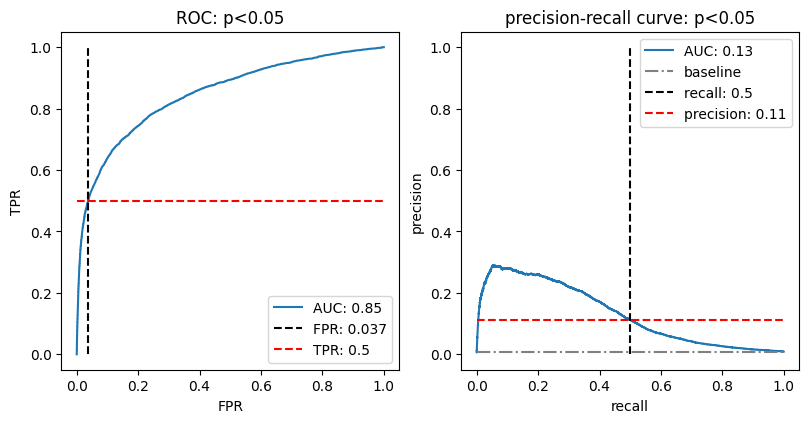

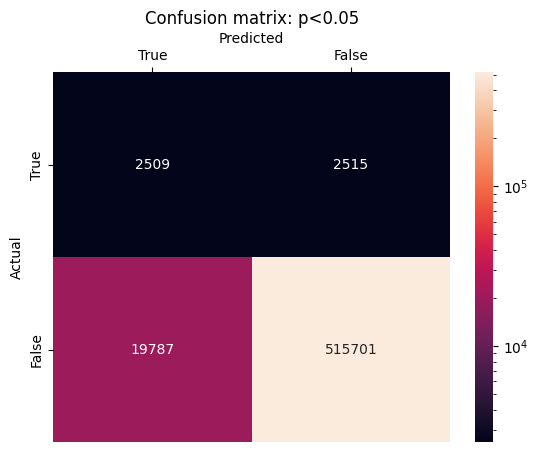

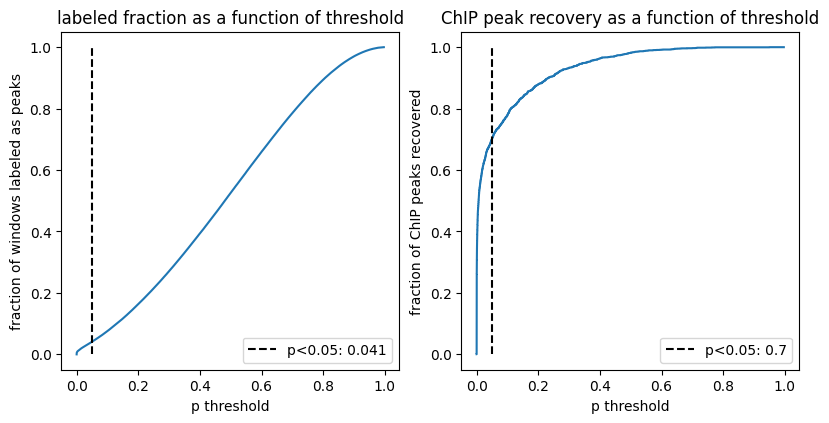

betabinom 500


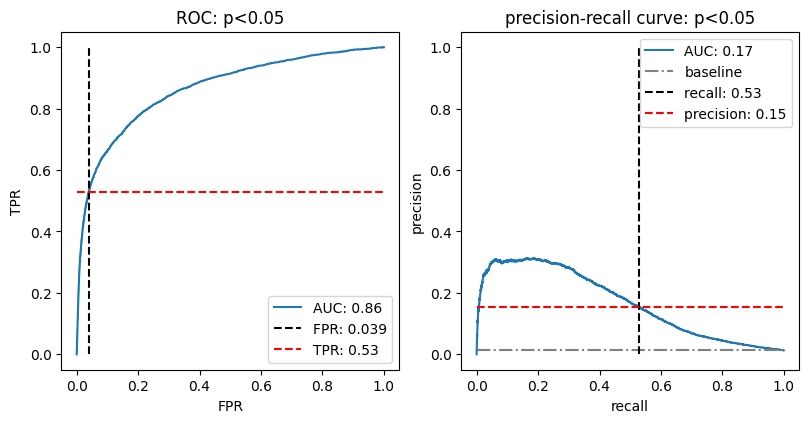

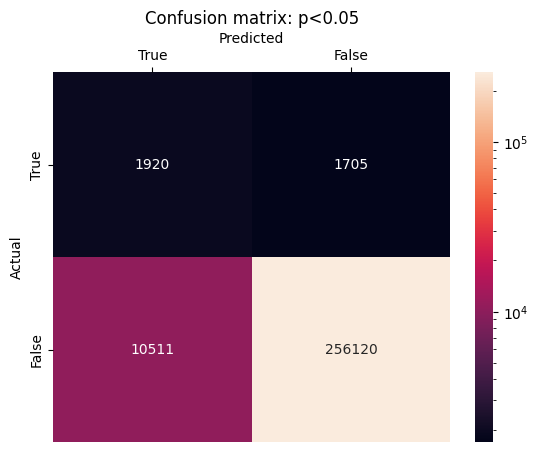

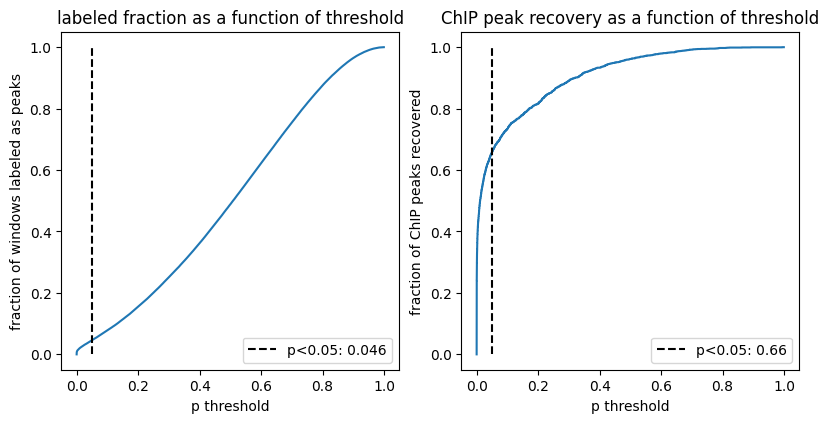

betabinom 1000


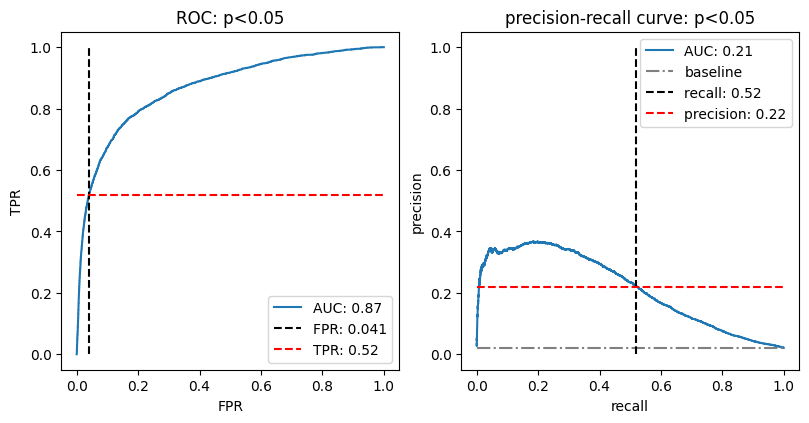

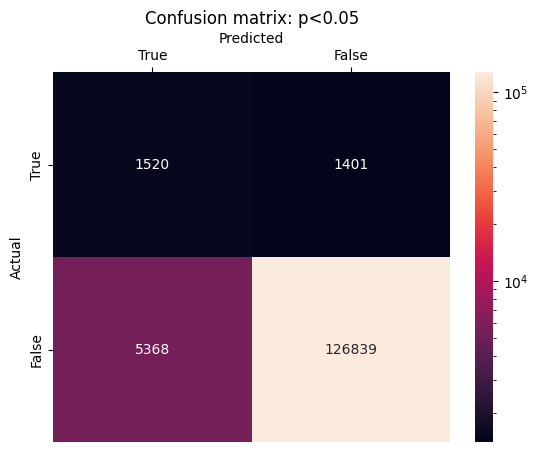

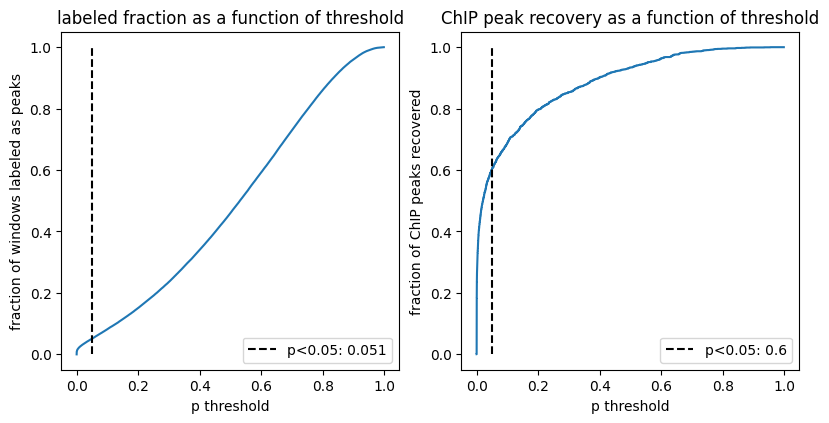

betabinom 2000


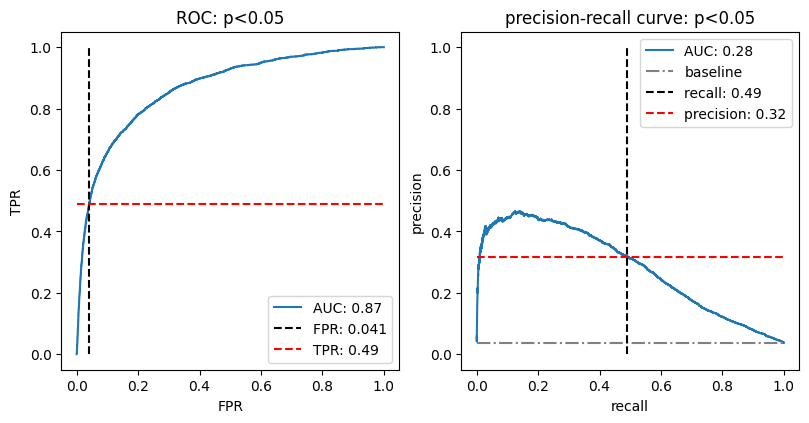

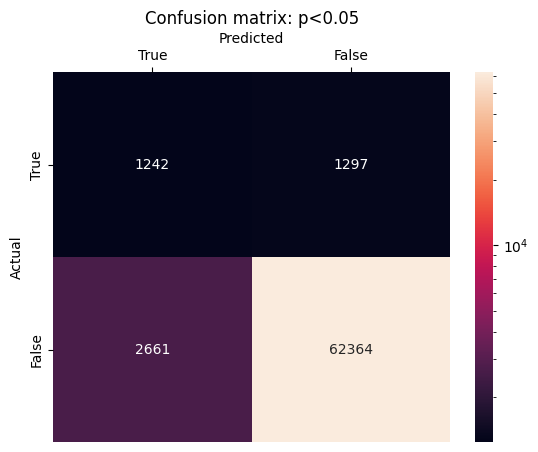

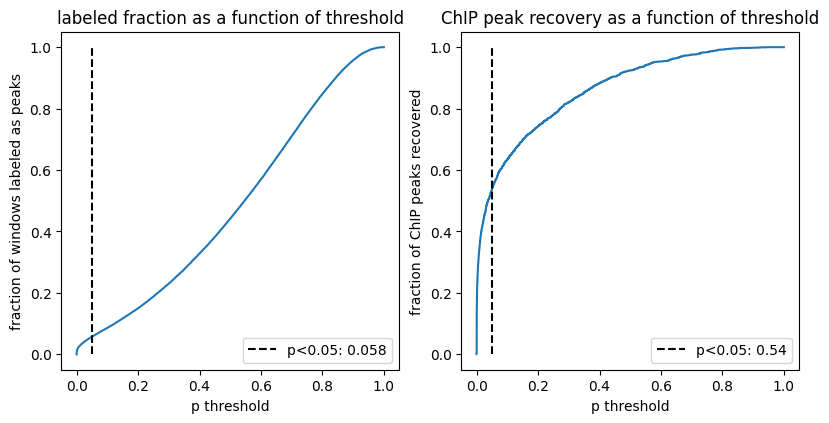

In [33]:
for distribution in ["betabinom"]:
    for window_size, labeled_stats_df in zip(window_sizes, distribution_result_dfs[distribution]):
        print(distribution, window_size)
        roc_prc_plot(labeled_stats_df, threshold=threshold)
        confusion_matrix_plot(labeled_stats_df, threshold=threshold)
        peak_label_plots(labeled_stats_df, threshold=threshold)

# Single read analysis

In [1]:
from pathlib import Path
import subprocess

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from dimelo import parse_bam, load_processed
import config, utils

import memray
import cProfile
import pstats

In [76]:
ctcf_chip_peak_file = config.processed_data_dir / "ENCFF797SDL.t2t_chm13v2.bed"
genome_index_file = config.raw_data_dir / "chm13v2.0.fa.fai"
genome_file = config.raw_data_dir / "chm13v2.0.fa"
ctcf_bam_file = config.processed_data_dir / "20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam"

output_dir = config.working_dir / "review_data" / "single_read"
ctcf_chip_peak_centers_file = output_dir / ctcf_chip_peak_file.with_suffix(".centers.bed").name
ctcf_peak_regions_file =  output_dir / ctcf_chip_peak_file.with_suffix(".regions.bed").name

ctcf_output_id = f"{ctcf_bam_file.stem}.{ctcf_peak_regions_file.stem}"
# 400 / 2
window_size = 200
motifs = ["A,0", "WCG,1", "GCH,1"]
n_cores = 10
thresh = 0.95

In [3]:
# TODO: Use this in the third party data notebook; way quicker
subprocess.run(f"awk -F '\t' 'BEGIN {{OFS=FS}} {{midpoint = int(($3 + $2) / 2); $2 = midpoint; $3 = midpoint + 1; print}}' {ctcf_chip_peak_file} > {ctcf_chip_peak_centers_file}", shell=True)
subprocess.run(f"bedtools slop -i {ctcf_chip_peak_centers_file} -g {genome_index_file} -b {window_size}  > {ctcf_peak_regions_file}", shell=True)

CompletedProcess(args='bedtools slop -i /Users/jeremy/devspace/multimodal-dimelo/review_data/single_read/ENCFF797SDL.t2t_chm13v2.centers.bed -g /Users/jeremy/devspace/multimodal-dimelo/data/raw/chm13v2.0.fa.fai -b 200  > /Users/jeremy/devspace/multimodal-dimelo/review_data/single_read/ENCFF797SDL.t2t_chm13v2.regions.bed', returncode=0)

In [ ]:
parse_bam.extract(
    input_file=ctcf_bam_file,
    output_name=f"extract.{ctcf_output_id}",
    ref_genome=genome_file,
    output_directory=output_dir,
    regions=ctcf_peak_regions_file,
    motifs=motifs,
    thresh=None, # TODO: No thresholding at extract time?
    cores=n_cores,
    override_checks=True,
)

awk '$1 == "chr1"' /Users/jeremy/devspace/multimodal-dimelo/review_data/single_read/ENCFF797SDL.t2t_chm13v2.regions.chr1.bed > /Users/jeremy/devspace/multimodal-dimelo/review_data/single_read/ENCFF797SDL.t2t_chm13v2.regions.chr1.bed


In [77]:
# Temporarily just look at one chromosome for speed and memory
target_chrom = "chr11"
target_file = output_dir / ctcf_chip_peak_file.with_suffix(".regions.chrX.bed").name
subprocess.run(f"awk '$1 == \"{target_chrom}\"' {ctcf_peak_regions_file} > {target_file}", shell=True)
ctcf_peak_regions_file = target_file

In [78]:
regions_df = utils.load_encode_narrowpeak_bed(ctcf_peak_regions_file)
regions_df["window_spec"] = regions_df["chrom"] + ":" + regions_df["chromStart"].astype("str") + "-" + regions_df["chromEnd"].astype("str")

<Axes: >

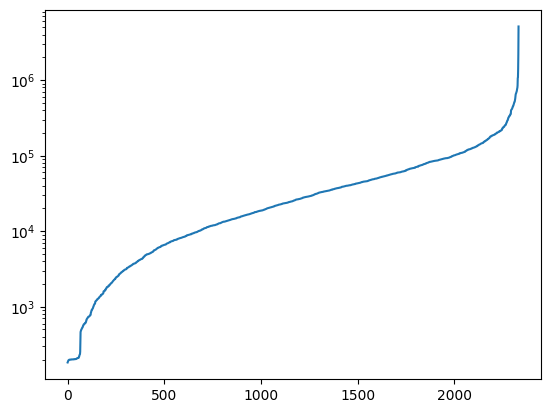

In [79]:
regions_df["chromStart"].sort_values().diff().sort_values(ignore_index=True).plot(logy=True)

In [47]:
def generate_streak_info(results: pd.Series):
    """
    https://joshdevlin.com/blog/calculate-streaks-in-pandas/
    """
    streak_ids = results.ne(results.shift()).cumsum()
    streak_counter = streak_ids.groupby(streak_ids).cumcount() + 1
    return streak_counter

In [54]:
regions_df["chromEnd"] - regions_df["chromStart"]

0       401
1       401
2       401
3       401
4       401
       ... 
2330    401
2331    401
2332    401
2333    401
2334    401
Length: 2335, dtype: int64

In [62]:
seq = regions_df["chromStart"].sort_values(ignore_index=True).diff() < 79674
streak_counter = generate_streak_info(seq)
pd.concat([seq, streak_counter], axis="columns")

,chromStart,0
0,False,1
1,True,1
2,True,2
3,True,3
4,True,4
...,...,...
2330,False,1
2331,False,2
2332,False,3
2333,True,1


In [63]:
streak_counter[seq].max()

np.int64(66)

In [80]:
sorted_read_data_converted, datasets, regions_dict = load_processed.read_vectors_from_hdf5(
    file=output_dir / f"extract.{ctcf_output_id}" / "reads.combined_basemods.h5",
    motifs=motifs,
    regions=ctcf_peak_regions_file,
    window_size=None,
    calculate_mod_fractions=False,
    span_full_window=True
)

In [6]:
from collections import Counter

In [7]:
for k, v in Counter(Counter([read_tuple[datasets.index("read_name")] for read_tuple in sorted_read_data_converted]).values()).items():
    print(f"{k:>2}: {v}")

 3: 33401
12: 534
 9: 1739
 6: 6955
 2: 6412
 1: 22
 4: 281
 5: 25
11: 3
15: 123
18: 73
 8: 10
21: 30
27: 4
36: 1
24: 5
33: 1
39: 1
 7: 3
30: 1
14: 1


In [8]:
Counter([read_tuple[datasets.index("read_name")] for read_tuple in sorted_read_data_converted])

Counter({'dfe2b30b-bd7d-4b0f-8103-f92483032955': 39,
         '5eeed69f-aaca-4bd8-a37f-b6fc899c0a7e': 36,
         'b5f960fb-585c-4086-8e98-05115a044e85': 33,
         '1c882b1f-72b3-4ef1-aa15-5d43dd3e5797': 30,
         'b4f91546-68b3-48e5-a12f-3f60c8eb4d4f': 27,
         'c71a94c5-621b-40ee-811a-9da31e0f8c46': 27,
         'a09c184f-98df-4464-b552-90c6e174f968': 27,
         '93821a59-9b28-4e75-9873-0a932b82dbe4': 27,
         '57ca2932-52b0-4bc8-a5c5-353f870f62b5': 24,
         '5ebdd43f-348e-4e21-85b5-4f239eecda6a': 24,
         'a50eed0d-901e-4fa0-a7c3-0cba458f9e10': 24,
         '71702614-ef72-4a06-9fe7-790c8cef800d': 24,
         '01670791-c0e2-4b60-8694-fdc07c63ab0c': 24,
         'a6f299e2-31c1-4d13-995d-e577e138c581': 21,
         '5c447c98-32d0-4613-962c-662def158946': 21,
         '64ae0e43-9d3f-4deb-b951-0925ac80a778': 21,
         '8fca4043-afcd-43df-bab4-80efdfc04bd0': 21,
         '69597b49-6b95-43de-a2f2-01c108fd502a': 21,
         '9837be1b-38c7-4cfb-882a-0f45dcae87b0

In [9]:
test = [x for x in sorted_read_data_converted if x[datasets.index("read_name")] == "dfe2b30b-bd7d-4b0f-8103-f92483032955"]

In [10]:
[(x[datasets.index("motif")], len(x[datasets.index("mod_vector")])) for x in test]

[('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894)]

In [11]:
[(x[datasets.index("motif")], x[datasets.index("read_start")], x[datasets.index("read_end")]) for x in test]

[('A,0', np.int32(64274307), np.int32(64353981)),
 ('GCH,1', np.int32(64274307), np.int32(64353981)),
 ('WCG,1', np.int32(64274315), np.int32(64353976)),
 ('A,0', np.int32(64274307), np.int32(64353981)),
 ('GCH,1', np.int32(64274307), np.int32(64353981)),
 ('WCG,1', np.int32(64274315), np.int32(64353976)),
 ('A,0', np.int32(64274307), np.int32(64353981)),
 ('GCH,1', np.int32(64274307), np.int32(64353981)),
 ('WCG,1', np.int32(64274315), np.int32(64353976)),
 ('A,0', np.int32(64274307), np.int32(64353981)),
 ('GCH,1', np.int32(64274307), np.int32(64353981)),
 ('WCG,1', np.int32(64274315), np.int32(64353976)),
 ('A,0', np.int32(64274307), np.int32(64353981)),
 ('GCH,1', np.int32(64274307), np.int32(64353981)),
 ('WCG,1', np.int32(64274315), np.int32(64353976)),
 ('A,0', np.int32(64274307), np.int32(64353981)),
 ('GCH,1', np.int32(64274307), np.int32(64353981)),
 ('WCG,1', np.int32(64274315), np.int32(64353976)),
 ('A,0', np.int32(64274307), np.int32(64353981)),
 ('GCH,1', np.int32(642743

In [12]:
[(x[datasets.index("motif")], x[datasets.index("read_length")]) for x in test]

[('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1'

In [13]:
peak_overlap_counter = Counter([len(regions_df[(regions_df["chromStart"] >= x[datasets.index("read_start")]) & (regions_df["chromEnd"] <= x[datasets.index("read_end")])]) for x in sorted_read_data_converted])

In [14]:
peak_overlap_counter

Counter({1: 113081,
         2: 42900,
         3: 15792,
         4: 6448,
         5: 1845,
         6: 1314,
         7: 644,
         8: 120,
         9: 108,
         13: 39,
         12: 36,
         11: 33,
         10: 30})

In [15]:
for k, v in peak_overlap_counter.items():
    print(f"{k:>2}: {v / k / 3 if k != 0 else v}")

 1: 37693.666666666664
 4: 537.3333333333334
 3: 1754.6666666666667
 2: 7150.0
 5: 123.0
 6: 73.0
 7: 30.666666666666668
 9: 4.0
12: 1.0
 8: 5.0
11: 1.0
13: 1.0
10: 1.0


In [15]:
datasets

['chromosome',
 'mod_vector',
 'motif',
 'read_end',
 'read_name',
 'read_start',
 'strand',
 'val_vector',
 'region_start',
 'region_end',
 'region_strand',
 'read_length']

In [16]:
np.sum([np.sum(x[datasets.index("val_vector")]) == 0 for x in sorted_read_data_converted])

np.int64(528)

In [81]:
read_data_by_motif = {motif: [] for motif in motifs}
for read_tuple in sorted_read_data_converted:
    read_data_by_motif[read_tuple[datasets.index("motif")]].append(read_tuple)

In [82]:
read_data_by_motif_filtered = {motif: [] for motif in motifs}
for motif in motifs:
    seen = set()
    for read_tuple in read_data_by_motif[motif]:
        read_name = read_tuple[datasets.index("read_name")]
        if read_name not in seen:
            read_data_by_motif_filtered[motif].append(read_tuple)
            seen.add(read_name)

In [36]:
for k, v in read_data_by_motif.items():
    print(k, len(v))

A,0 38051
WCG,1 32222
GCH,1 38043


In [20]:
for k, v in read_data_by_motif_filtered.items():
    print(k, len(v))

A,0 49615
WCG,1 42909
GCH,1 49602


In [83]:
motif_read_region_mod_fracs = {}
for motif in motifs:
    # NOTE: This only works because I'm setting `span_full_window` to True. Otherwise I would need to handle partial overlaps better. Same goes for analysis above.
    read_dfs = []
    for read_tuple in read_data_by_motif_filtered[motif]:
        overlapping_regions = regions_df[(regions_df["chromStart"] >= read_tuple[datasets.index("read_start")]) & (regions_df["chromEnd"] <= read_tuple[datasets.index("read_end")])]

        mod_vec = read_tuple[datasets.index("mod_vector")] >= thresh
        read_region_indices = (overlapping_regions[["chromStart", "chromEnd"]] - read_tuple[datasets.index("read_start")])
        mod_counts = read_region_indices.apply(lambda row: mod_vec[row["chromStart"]: row["chromEnd"]].sum(), axis="columns")
        valid_counts = read_region_indices.apply(lambda row: read_tuple[datasets.index("val_vector")][row["chromStart"]: row["chromEnd"]].sum(), axis="columns")
        read_df = pd.concat([(mod_counts/valid_counts).rename("mod_frac"), overlapping_regions["window_spec"]], axis="columns")
        read_df["read_name"] = read_tuple[datasets.index("read_name")]
        read_dfs.append(read_df)
    motif_read_region_mod_fracs[motif] = pd.concat(read_dfs)

In [29]:
motif_read_region_mod_fracs["GCH,1"]

,mod_frac,window_spec,read_name
1668,0.266667,chr11:221149-221550,85f041b5-1508-4454-90d8-33a3e97c050c
1626,0.044444,chr11:230402-230803,1d0f65fa-b955-4b2e-8ed2-68783c952f9a
1668,0.062500,chr11:221149-221550,1d0f65fa-b955-4b2e-8ed2-68783c952f9a
2060,0.222222,chr11:230639-231040,1d0f65fa-b955-4b2e-8ed2-68783c952f9a
2071,0.000000,chr11:232659-233060,1d0f65fa-b955-4b2e-8ed2-68783c952f9a
...,...,...,...
1355,0.000000,chr11:135123825-135124226,9df022ab-0076-465b-820d-3db52ae4a2b4
1355,0.032258,chr11:135123825-135124226,bc189ff4-ef66-4f5a-a338-89b0182d7f00
1355,0.000000,chr11:135123825-135124226,2a9c4de6-2adc-44a7-9e9d-ce6797d0eba5
1355,0.040000,chr11:135123825-135124226,477c066e-c1dd-4ef4-8edd-d7d03d96c0a9


In [31]:
[(k, len(v)) for k, v in motif_read_region_mod_fracs.items()]

[('A,0', 63151), ('WCG,1', 56104), ('GCH,1', 63135)]

In [84]:
A_CG_df = pd.merge(motif_read_region_mod_fracs["A,0"], motif_read_region_mod_fracs["WCG,1"], how="inner", on=["window_spec", "read_name"], suffixes=["_A", "_CG"])
# TODO: Understand the iloc indexing (something strange about multi-indexes) (also super annoyed df.corr only returns matrices)
per_site_A_CG_correlations = A_CG_df.groupby("window_spec")[["mod_frac_A", "mod_frac_CG"]].corr(method="pearson").iloc[0::2,-1]
per_site_A_CG_correlations.index = per_site_A_CG_correlations.index.droplevel(1)

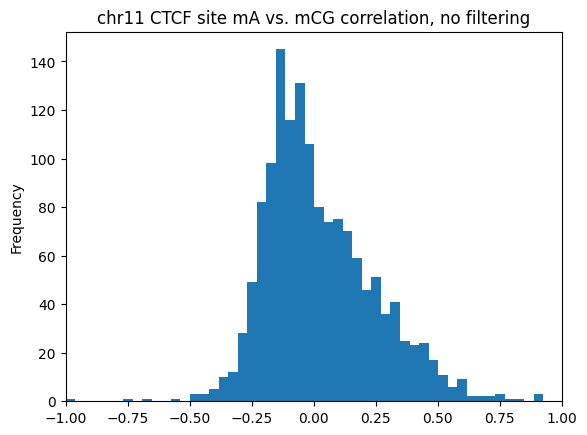

In [85]:
per_site_A_CG_correlations.plot.hist(bins=50)
plt.xlim((-1, 1))
plt.title(f"{target_chrom} CTCF site mA vs. mCG correlation, no filtering")
plt.show()

In [86]:
GC_CG_df = pd.merge(motif_read_region_mod_fracs["GCH,1"], motif_read_region_mod_fracs["WCG,1"], how="inner", on=["window_spec", "read_name"], suffixes=["_GC", "_CG"])
# TODO: Understand the iloc indexing (something strange about multi-indexes) (also super annoyed df.corr only returns matrices)
per_site_GC_CG_correlations = GC_CG_df.groupby("window_spec")[["mod_frac_GC", "mod_frac_CG"]].corr(method="pearson").iloc[0::2,-1]
per_site_GC_CG_correlations.index = per_site_GC_CG_correlations.index.droplevel(1)

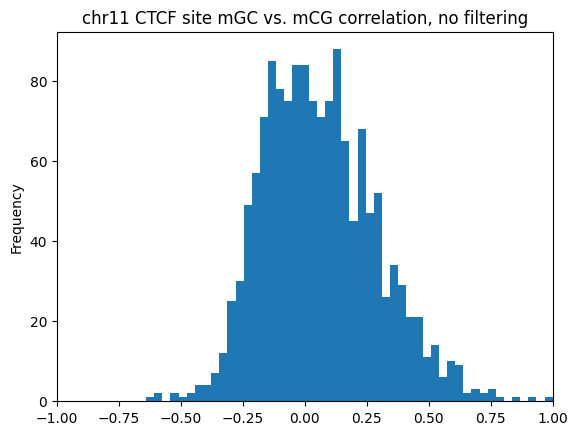

In [87]:
per_site_GC_CG_correlations.plot.hist(bins=50)
plt.xlim((-1, 1))
plt.title(f"{target_chrom} CTCF site mGC vs. mCG correlation, no filtering")
plt.show()

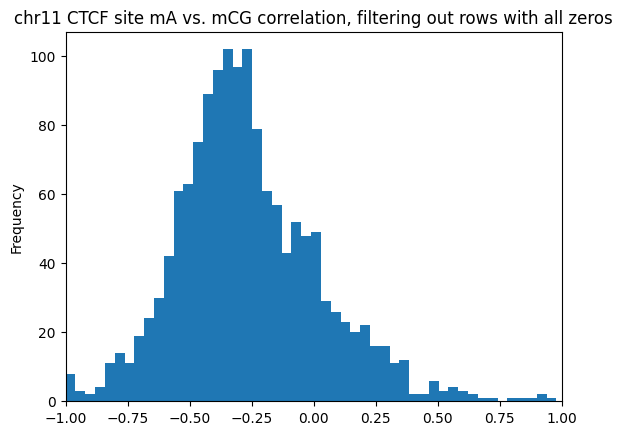

In [88]:
test = A_CG_df[~(A_CG_df[["mod_frac_A", "mod_frac_CG"]] == 0).all(axis="columns")]
test_correlations = test.groupby("window_spec")[["mod_frac_A", "mod_frac_CG"]].corr(method="pearson").iloc[0::2,-1]
test_correlations.index = test_correlations.index.droplevel(1)

test_correlations.plot.hist(bins=50)
plt.xlim((-1, 1))
plt.title(f"{target_chrom} CTCF site mA vs. mCG correlation, filtering out rows with all zeros")
plt.show()

<Axes: ylabel='Frequency'>

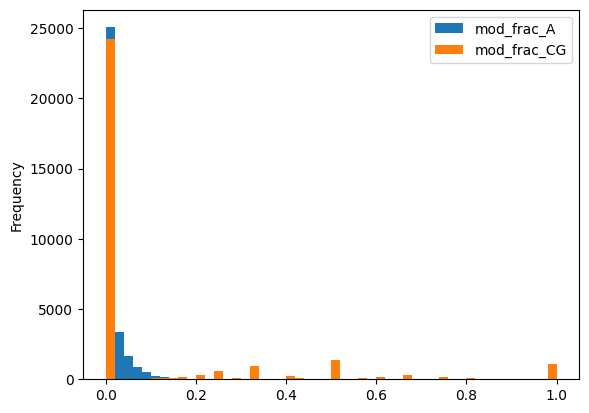

In [ ]:
A_CG_df[["mod_frac_A", "mod_frac_CG"]].plot.hist(bins=50)